# Loan Limit Optimization Model

## Objective
Develop an advanced model to determine the optimal loan limit increase policy while balancing profitability and minimizing default risks.

## Modules
1. Data Preprocessing & Exploratory Analysis
2. Markov Chain Model for Risk State Transitions
3. Stochastic Demand Forecasting
4. Loan Lifecycle Simulation (Monte Carlo)
5. Optimization Engine
6. Results & Reporting

## Key Assumptions
- Profit per successful increase: $40
- Eligibility threshold: 60 days since last loan disbursement
- Maximum increases per customer per year: 6
- Annual discount rate for NPV: 19%

---
## Module 1: Data Preprocessing & Exploratory Analysis

In [ ]:
pip install pandas numpy scipy matplotlib seaborn scikit-learn jupyter


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Standard library imports
import os
import logging
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis and ML
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Create output directory
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

# Global constants
PROFIT_PER_INCREASE = 40
ELIGIBILITY_THRESHOLD_DAYS = 60
MAX_INCREASES_PER_YEAR = 6
DISCOUNT_RATE = 0.19

logger.info('Libraries loaded and output directory created')

2026-06-12 00:43:13,122 - INFO - Libraries loaded and output directory created


### 1.1 Data Loading and Validation

In [ ]:
# Load the dataset
DATA_PATH = 'loan_limit_increases.csv'
df = pd.read_csv(DATA_PATH)

# Rename columns for easier handling
df.columns = ['customer_id', 'initial_loan', 'days_since_last_loan', 
              'ontime_payment_pct', 'num_increases_2023', 'total_profit']

logger.info(f'Dataset loaded: {len(df):,} records, {len(df.columns)} columns')

print('=== Dataset Overview ===')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\nColumn Data Types:')
print(df.dtypes)
print(f'\nFirst 10 Records:')
display(df.head(10))

2026-06-12 00:43:13,132 - INFO - Dataset loaded: 30,000 records, 6 columns


=== Dataset Overview ===
Rows: 30,000
Columns: 6

Column Data Types:
customer_id               int64
initial_loan              int64
days_since_last_loan      int64
ontime_payment_pct      float64
num_increases_2023        int64
total_profit              int64
dtype: object

First 10 Records:


,customer_id,initial_loan,days_since_last_loan,ontime_payment_pct,num_increases_2023,total_profit
0,1001,1360,72,90.41,5,120
1,1002,4272,54,90.32,0,0
2,1003,3592,242,85.56,4,80
3,1004,966,301,95.86,0,0
4,1005,4926,352,94.80,0,0
5,1006,3944,214,84.68,4,80
6,1007,3671,14,86.40,0,0
7,1008,3419,146,95.77,0,0
8,1009,630,143,87.15,0,0
9,1010,2185,24,88.07,3,40


In [ ]:
# Data validation checks
print('=== Data Quality Checks ===')

# Missing values
print(f'\nMissing values per column:')
print(df.isnull().sum())

# Duplicate IDs
print(f'\nDuplicate customer IDs: {df["customer_id"].duplicated().sum()}')

# Profit validation - this reveals the critical business insight
df['expected_profit'] = df['num_increases_2023'] * PROFIT_PER_INCREASE
df['profit_mismatch'] = df['total_profit'] != df['expected_profit']
mismatch_count = df['profit_mismatch'].sum()
print(f'\nProfit calculation mismatches: {mismatch_count:,} ({mismatch_count/len(df)*100:.1f}%)')

# Value ranges
print(f'\n=== Value Ranges ===')
print(f"Initial Loan: ${df['initial_loan'].min():,} - ${df['initial_loan'].max():,}")
print(f"Days Since Last Loan: {df['days_since_last_loan'].min()} - {df['days_since_last_loan'].max()}")
print(f"On-time Payment %: {df['ontime_payment_pct'].min():.1f}% - {df['ontime_payment_pct'].max():.1f}%")
print(f"Number of Increases: {df['num_increases_2023'].min()} - {df['num_increases_2023'].max()}")

logger.info('Data validation completed')

2026-06-12 00:43:13,141 - INFO - Data validation completed


=== Data Quality Checks ===

Missing values per column:
customer_id             0
initial_loan            0
days_since_last_loan    0
ontime_payment_pct      0
num_increases_2023      0
total_profit            0
dtype: int64

Duplicate customer IDs: 0

Profit calculation mismatches: 16,793 (56.0%)

=== Value Ranges ===
Initial Loan: $500 - $4,999
Days Since Last Loan: 0 - 364
On-time Payment %: 80.0% - 100.0%
Number of Increases: 0 - 5


### 1.2 Comprehensive Descriptive Statistics

This section provides a detailed analysis of the dataset's key variables, distributions, and business metrics.

In [ ]:
def analyze_distributions(df: pd.DataFrame) -> dict:
    """
    Analyze distributions of key numerical variables.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with loan data
        
    Returns:
    --------
    dict : Dictionary containing distribution statistics
    """
    results = {}
    
    print('=' * 60)
    print('DISTRIBUTION ANALYSIS')
    print('=' * 60)
    
    # Initial loan distribution
    print('\n--- Initial Loan Distribution ---')
    print(f"  Mean: ${df['initial_loan'].mean():,.0f}")
    print(f"  Median: ${df['initial_loan'].median():,.0f}")
    print(f"  Std Dev: ${df['initial_loan'].std():,.0f}")
    skewness = stats.skew(df['initial_loan'])
    print(f"  Skewness: {skewness:.3f} (near 0 = symmetric distribution)")
    results['initial_loan_skew'] = skewness
    
    # Days since last loan
    print('\n--- Days Since Last Loan ---')
    print(f"  Mean: {df['days_since_last_loan'].mean():.1f} days")
    print(f"  Median: {df['days_since_last_loan'].median():.1f} days")
    eligible_count = (df['days_since_last_loan'] >= ELIGIBILITY_THRESHOLD_DAYS).sum()
    eligible_pct = eligible_count / len(df) * 100
    print(f"  Customers eligible (>={ELIGIBILITY_THRESHOLD_DAYS} days): {eligible_count:,} ({eligible_pct:.1f}%)")
    results['eligible_count'] = eligible_count
    results['eligible_pct'] = eligible_pct
    
    # On-time payment percentage
    print('\n--- On-time Payment % ---')
    print(f"  Mean: {df['ontime_payment_pct'].mean():.2f}%")
    print(f"  Median: {df['ontime_payment_pct'].median():.2f}%")
    print(f"  Std Dev: {df['ontime_payment_pct'].std():.2f}%")
    print(f"  Range: {df['ontime_payment_pct'].min():.2f}% - {df['ontime_payment_pct'].max():.2f}%")
    
    # Number of increases distribution
    print('\n--- Number of Increases Distribution ---')
    increase_dist = df['num_increases_2023'].value_counts().sort_index()
    for increases, count in increase_dist.items():
        pct = count / len(df) * 100
        print(f"  {increases} increases: {count:,} customers ({pct:.1f}%)")
    
    # Highlight bimodal pattern
    no_increases = (df['num_increases_2023'] == 0).sum()
    any_increases = (df['num_increases_2023'] > 0).sum()
    print(f'\n  Customers with 0 increases: {no_increases:,} ({no_increases/len(df)*100:.1f}%)')
    print(f'  Customers with any increase: {any_increases:,} ({any_increases/len(df)*100:.1f}%)')
    
    # Check for bimodal pattern (no 1 or 2 increases)
    one_two_count = df['num_increases_2023'].isin([1, 2]).sum()
    if one_two_count == 0:
        print(f'  NOTE: Bimodal distribution - no customers with 1 or 2 increases!')
    
    results['no_increases'] = no_increases
    results['any_increases'] = any_increases
    
    return results

distribution_stats = analyze_distributions(df)

DISTRIBUTION ANALYSIS

--- Initial Loan Distribution ---
  Mean: $2,753
  Median: $2,761
  Std Dev: $1,293
  Skewness: -0.007 (near 0 = symmetric distribution)

--- Days Since Last Loan ---
  Mean: 181.5 days
  Median: 182.0 days
  Customers eligible (>=60 days): 25,068 (83.6%)

--- On-time Payment % ---
  Mean: 90.02%
  Median: 90.05%
  Std Dev: 5.75%
  Range: 80.00% - 100.00%

--- Number of Increases Distribution ---
  0 increases: 13,207 customers (44.0%)
  3 increases: 5,665 customers (18.9%)
  4 increases: 5,510 customers (18.4%)
  5 increases: 5,618 customers (18.7%)

  Customers with 0 increases: 13,207 (44.0%)
  Customers with any increase: 16,793 (56.0%)
  NOTE: Bimodal distribution - no customers with 1 or 2 increases!


In [ ]:
def analyze_profit_metrics(df: pd.DataFrame) -> dict:
    """
    Analyze profit metrics and identify default patterns.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with loan data
        
    Returns:
    --------
    dict : Dictionary containing profit analysis results
    """
    results = {}
    
    print('=' * 60)
    print('PROFIT ANALYSIS - CRITICAL BUSINESS INSIGHTS')
    print('=' * 60)
    
    # Overall profit summary
    total_expected = df['expected_profit'].sum()
    total_actual = df['total_profit'].sum()
    profit_shortfall = total_expected - total_actual
    overall_default_rate = profit_shortfall / total_expected if total_expected > 0 else 0
    
    print('\n--- Overall Profit Summary ---')
    print(f"  Total Expected Profit: ${total_expected:,.0f}")
    print(f"  Total Actual Profit: ${total_actual:,.0f}")
    print(f"  Profit Shortfall (Due to Defaults): ${profit_shortfall:,.0f}")
    print(f"  Overall Default Rate: {overall_default_rate*100:.2f}%")
    
    results['total_expected'] = total_expected
    results['total_actual'] = total_actual
    results['profit_shortfall'] = profit_shortfall
    results['overall_default_rate'] = overall_default_rate
    
    # For customers with increases only
    df_with_increases = df[df['num_increases_2023'] > 0].copy()
    if len(df_with_increases) > 0:
        avg_expected = df_with_increases['expected_profit'].mean()
        avg_actual = df_with_increases['total_profit'].mean()
        avg_loss = avg_expected - avg_actual
        
        # Calculate per-customer default rate
        df_with_increases['customer_default_rate'] = (
            (df_with_increases['expected_profit'] - df_with_increases['total_profit']) / 
            df_with_increases['expected_profit']
        )
        avg_customer_default = df_with_increases['customer_default_rate'].mean()
        
        print(f'\n--- For Customers With Increases ({len(df_with_increases):,} customers) ---')
        print(f"  Avg Expected Profit: ${avg_expected:.2f}")
        print(f"  Avg Actual Profit: ${avg_actual:.2f}")
        print(f"  Avg Profit Loss per Customer: ${avg_loss:.2f}")
        print(f"  Average Default Rate: {avg_customer_default*100:.2f}%")
        
        results['customers_with_increases'] = len(df_with_increases)
        results['avg_customer_default_rate'] = avg_customer_default
    
    return results

profit_stats = analyze_profit_metrics(df)

PROFIT ANALYSIS - CRITICAL BUSINESS INSIGHTS

--- Overall Profit Summary ---
  Total Expected Profit: $2,685,000
  Total Actual Profit: $1,341,560
  Profit Shortfall (Due to Defaults): $1,343,440
  Overall Default Rate: 50.04%

--- For Customers With Increases (16,793 customers) ---
  Avg Expected Profit: $159.89
  Avg Actual Profit: $79.89
  Avg Profit Loss per Customer: $80.00
  Average Default Rate: 52.28%


In [ ]:
def analyze_payment_segments(df: pd.DataFrame) -> pd.DataFrame:
    """
    Analyze default rates by payment behavior segments.
    This is a critical analysis to understand if payment behavior predicts defaults.
    """
    print('=' * 60)
    print('PAYMENT BEHAVIOR SEGMENTS ANALYSIS')
    print('=' * 60)
    
    # Create payment segments
    df = df.copy()
    df['payment_segment'] = pd.cut(
        df['ontime_payment_pct'],
        bins=[0, 85, 90, 95, 100],
        labels=['80-85%', '85-90%', '90-95%', '95-100%'],
        include_lowest=True
    )
    
    # Analyze each segment
    segment_analysis = df.groupby('payment_segment', observed=True).agg({
        'customer_id': 'count',
        'num_increases_2023': 'mean',
        'total_profit': 'sum',
        'expected_profit': 'sum',
        'ontime_payment_pct': 'mean'
    }).rename(columns={
        'customer_id': 'customer_count',
        'num_increases_2023': 'avg_increases',
        'total_profit': 'actual_profit',
        'ontime_payment_pct': 'avg_payment_pct'
    })
    
    # Calculate default rate per segment
    segment_analysis['default_rate'] = (
        (segment_analysis['expected_profit'] - segment_analysis['actual_profit']) /
        segment_analysis['expected_profit'] * 100
    )
    
    print('\n--- Default Rates by Payment Segment ---')
    display(segment_analysis.round(2))
    
    # Critical finding check
    default_rates = segment_analysis['default_rate'].values
    if max(default_rates) - min(default_rates) < 5:  # Less than 5% variation
        print('Default rate is UNIFORM across all payment segments (~50%)!')
        print('This suggests the current policy does NOT effectively use payment history.')
    
    return segment_analysis

segment_analysis = analyze_payment_segments(df)

PAYMENT BEHAVIOR SEGMENTS ANALYSIS

--- Default Rates by Payment Segment ---


,customer_count,avg_increases,actual_profit,expected_profit,avg_payment_pct,default_rate
payment_segment,,,,,,
80-85%,7385,2.25,332760,665000,82.49,49.96
85-90%,7551,2.23,336880,673520,87.51,49.98
90-95%,7560,2.22,334320,670400,92.52,50.13
95-100%,7504,2.25,337600,676080,97.45,50.07


Default rate is UNIFORM across all payment segments (~50%)!
This suggests the current policy does NOT effectively use payment history.


In [ ]:
def analyze_correlations(df: pd.DataFrame) -> pd.Series:
    """
    Analyze correlations between features and number of increases.
    """
    print('=' * 60)
    print('CORRELATION ANALYSIS')
    print('=' * 60)
    
    # Calculate correlations
    numeric_cols = ['initial_loan', 'days_since_last_loan', 'ontime_payment_pct', 'num_increases_2023']
    correlations = df[numeric_cols].corr()['num_increases_2023'].drop('num_increases_2023')
    
    print('\n--- Key Correlations with num_increases_2023 ---')
    print(f"  On-time Payment %: {correlations['ontime_payment_pct']:.4f}")
    print(f"  Initial Loan: {correlations['initial_loan']:.4f}")
    print(f"  Days Since Last Loan: {correlations['days_since_last_loan']:.4f}")
    
    # Critical finding check
    if abs(correlations['ontime_payment_pct']) < 0.01:
        print('Correlations are essentially ZERO! \n This means increases were NOT based on payment history or loan amount. \nThere is significant optimization needed')
    
    return correlations

correlations = analyze_correlations(df)
logger.info('Descriptive statistics analysis completed')

2026-06-12 00:43:13,181 - INFO - Descriptive statistics analysis completed


CORRELATION ANALYSIS

--- Key Correlations with num_increases_2023 ---
  On-time Payment %: -0.0001
  Initial Loan: -0.0056
  Days Since Last Loan: 0.0036
Correlations are essentially ZERO! 
 This means increases were NOT based on payment history or loan amount. 
There is significant optimization needed


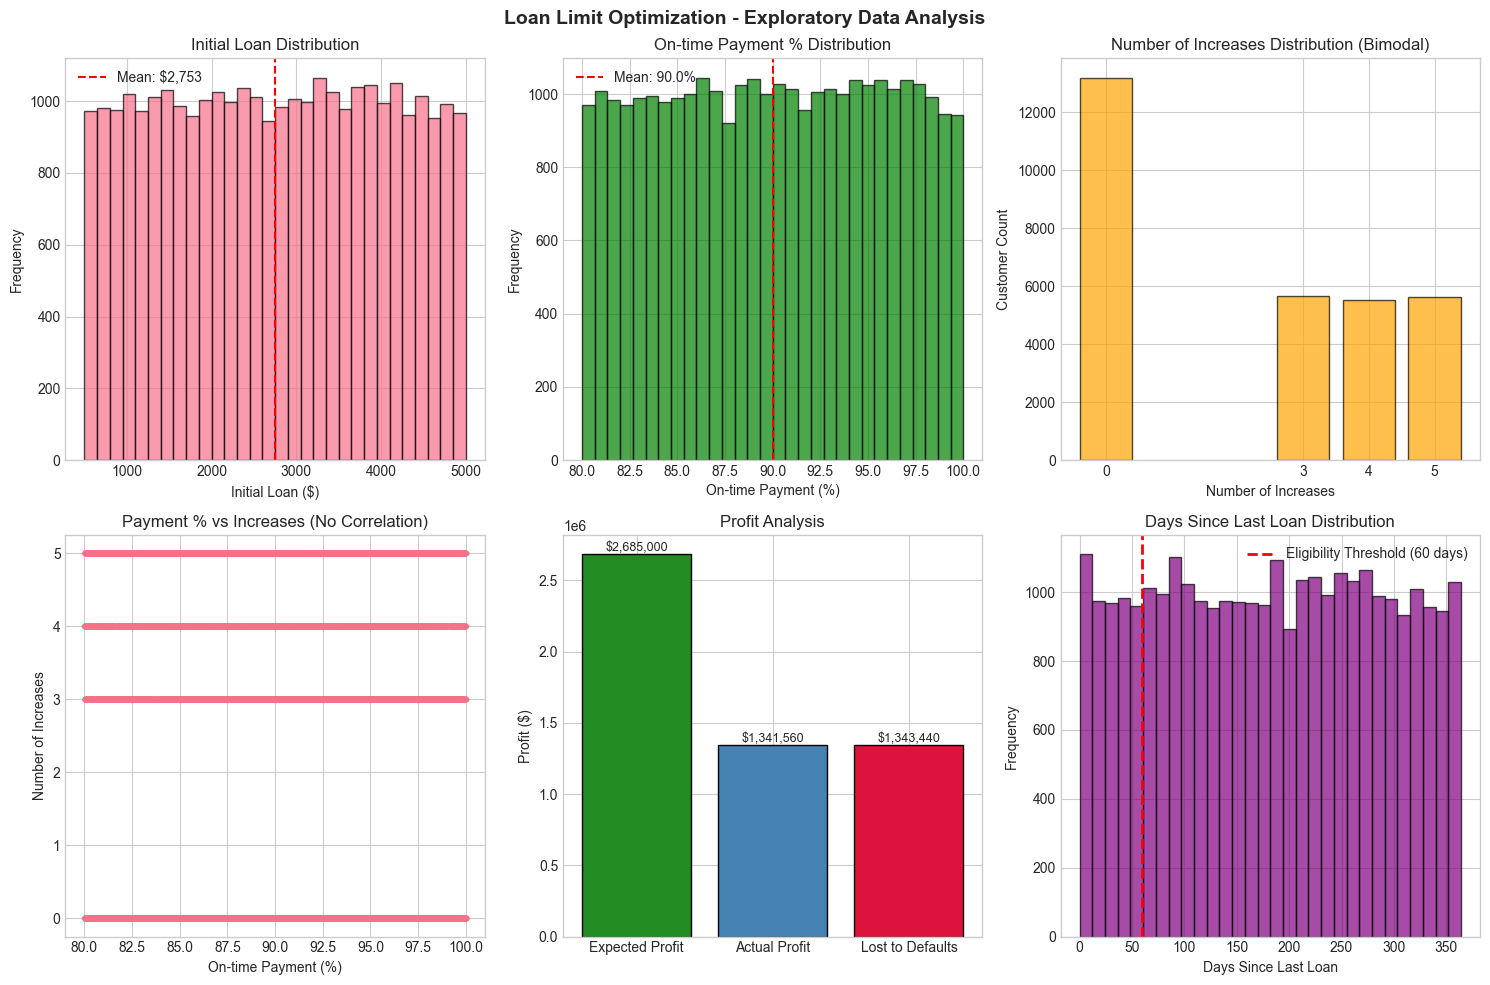

2026-06-12 00:43:13,657 - INFO - EDA visualizations created and saved


In [ ]:
def create_descriptive_visualizations(df: pd.DataFrame) -> None:
    """Create comprehensive visualizations for exploratory data analysis."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Loan Limit Optimization - Exploratory Data Analysis', fontsize=14, fontweight='bold')
    
    # 1. Initial loan distribution
    axes[0, 0].hist(df['initial_loan'], bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Initial Loan Distribution')
    axes[0, 0].set_xlabel('Initial Loan ($)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(df['initial_loan'].mean(), color='red', linestyle='--', label=f"Mean: ${df['initial_loan'].mean():,.0f}")
    axes[0, 0].legend()
    
    # 2. Payment percentage distribution
    axes[0, 1].hist(df['ontime_payment_pct'], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].set_title('On-time Payment % Distribution')
    axes[0, 1].set_xlabel('On-time Payment (%)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(df['ontime_payment_pct'].mean(), color='red', linestyle='--', label=f"Mean: {df['ontime_payment_pct'].mean():.1f}%")
    axes[0, 1].legend()
    
    # 3. Number of increases distribution (bimodal)
    increase_counts = df['num_increases_2023'].value_counts().sort_index()
    axes[0, 2].bar(increase_counts.index, increase_counts.values, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 2].set_title('Number of Increases Distribution (Bimodal)')
    axes[0, 2].set_xlabel('Number of Increases')
    axes[0, 2].set_ylabel('Customer Count')
    axes[0, 2].set_xticks(increase_counts.index)
    
    # 4. Payment % vs Number of Increases (scatter)
    axes[1, 0].scatter(df['ontime_payment_pct'], df['num_increases_2023'], alpha=0.3, s=10)
    axes[1, 0].set_title('Payment % vs Increases (No Correlation)')
    axes[1, 0].set_xlabel('On-time Payment (%)')
    axes[1, 0].set_ylabel('Number of Increases')
    
    # 5. Profit comparison (expected vs actual)
    profit_data = {
        'Category': ['Expected Profit', 'Actual Profit', 'Lost to Defaults'],
        'Amount': [df['expected_profit'].sum(), df['total_profit'].sum(), 
                   df['expected_profit'].sum() - df['total_profit'].sum()]
    }
    colors = ['forestgreen', 'steelblue', 'crimson']
    axes[1, 1].bar(profit_data['Category'], profit_data['Amount'], color=colors, edgecolor='black')
    axes[1, 1].set_title('Profit Analysis')
    axes[1, 1].set_ylabel('Profit ($)')
    for i, v in enumerate(profit_data['Amount']):
        axes[1, 1].text(i, v + 20000, f'${v:,.0f}', ha='center', fontsize=9)
    
    # 6. Days since last loan distribution
    axes[1, 2].hist(df['days_since_last_loan'], bins=30, edgecolor='black', alpha=0.7, color='purple')
    axes[1, 2].axvline(ELIGIBILITY_THRESHOLD_DAYS, color='red', linestyle='--', linewidth=2, 
                       label=f'Eligibility Threshold ({ELIGIBILITY_THRESHOLD_DAYS} days)')
    axes[1, 2].set_title('Days Since Last Loan Distribution')
    axes[1, 2].set_xlabel('Days Since Last Loan')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eda_visualizations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info('EDA visualizations created and saved')

create_descriptive_visualizations(df)

### Summary of Key Findings from Descriptive Analysis

1. **HIGH DEFAULT RATE (~50%)**
   - Expected profit: $2,685,000
   - Actual profit: $1,341,560
   - Loss due to defaults: $1,343,440

2. **NO CORRELATION WITH PAYMENT BEHAVIOR**
   - Payment % vs Increases correlation: ~0.0001
   - Default rate is uniform (~50%) across ALL payment segments
   - Current policy appears to be random or not risk-based

3. **BIMODAL INCREASE DISTRIBUTION**
   - Customers either get 0 increases OR 3-5 increases
   - No customers with 1 or 2 increase

4. **MOST CUSTOMERS ARE ELIGIBLE**
   - 83.6% of customers have >=60 days since last loan
   - But only 56.0% received any increases

5. **OPTIMIZATION OPPORTUNITY**
   - If we can reduce default rate from 50% to 25%:
   - Potential additional profit: $671,720
   - Key: Use payment behavior to target low-risk customers

### 1.3 Profit Mismatch Analysis

This section derives default rates from the profit data by analyzing the gap between expected and actual profits.

In [ ]:
def analyze_profit_mismatch(df: pd.DataFrame) -> pd.DataFrame:
    """
    Analyze profit mismatch to derive default patterns.
    
    The key insight: If expected profit = increases * $40 and actual profit is less,
    the difference represents defaults (customers who received increases but defaulted).
    """
    print('=== Profit Mismatch Analysis ===')
    
    df = df.copy()
    
    # Categorize profit status
    df['profit_status'] = 'Match'
    df.loc[df['total_profit'] < df['expected_profit'], 'profit_status'] = 'Under (Possible Default)'
    
    print('\nProfit Status Distribution:')
    print(df['profit_status'].value_counts())
    
    # Analyze by number of increases for customers with increases
    df_with_increases = df[df['num_increases_2023'] > 0].copy()
    print(f'\nCustomers who received at least one increase: {len(df_with_increases)}')
    
    profit_by_increases = df_with_increases.groupby('num_increases_2023').agg({
        'customer_id': 'count',
        'expected_profit': 'mean',
        'total_profit': 'mean'
    }).rename(columns={'customer_id': 'count'})
    
    profit_by_increases['avg_profit_diff'] = profit_by_increases['total_profit'] - profit_by_increases['expected_profit']
    profit_by_increases['mismatch_rate'] = 1 - (profit_by_increases['total_profit'] / profit_by_increases['expected_profit'])
    
    print('\nProfit Analysis by Number of Increases:')
    display(profit_by_increases)
    
    return df

df = analyze_profit_mismatch(df)

In [ ]:
def derive_default_rates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive customer-level default rates from profit data.
    """
    print('=== Deriving Default Rates from Profit Data ===')
    
    df = df.copy()
    
    # For customers with increases, calculate their implied default rate
    # Default rate = (Expected - Actual) / Expected
    mask = df['num_increases_2023'] > 0
    df.loc[mask, 'customer_default_rate'] = (
        (df.loc[mask, 'expected_profit'] - df.loc[mask, 'total_profit']) / 
        df.loc[mask, 'expected_profit']
    )
    
    # For customers without increases, we cannot derive a default rate
    # We will impute this later based on payment behavior
    df.loc[~mask, 'customer_default_rate'] = np.nan
    
    print('\nDefault Rate Statistics (for customers with increases):')
    print(df.loc[mask, 'customer_default_rate'].describe())
    
    print(f'\nCustomers with calculated default rate: {mask.sum():,}')
    print(f'Customers without increases (default rate TBD): {(~mask).sum():,}')
    
    return df

df = derive_default_rates(df)

=== Deriving Default Rates from Profit Data ===

Default Rate Statistics (for customers with increases):
count    16793.000000
mean         0.522769
std          0.110446
min          0.400000
25%          0.400000
50%          0.500000
75%          0.666667
max          0.666667
Name: customer_default_rate, dtype: float64

Customers with calculated default rate: 16,793
Customers without increases (default rate TBD): 13,207


### 1.4 Clustering Analysis (K-Means with 6 Clusters)

This section performs customer segmentation using K-Means clustering to explore whether 
different customer segments exhibit different behaviors regarding loan increases and defaults.

/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users

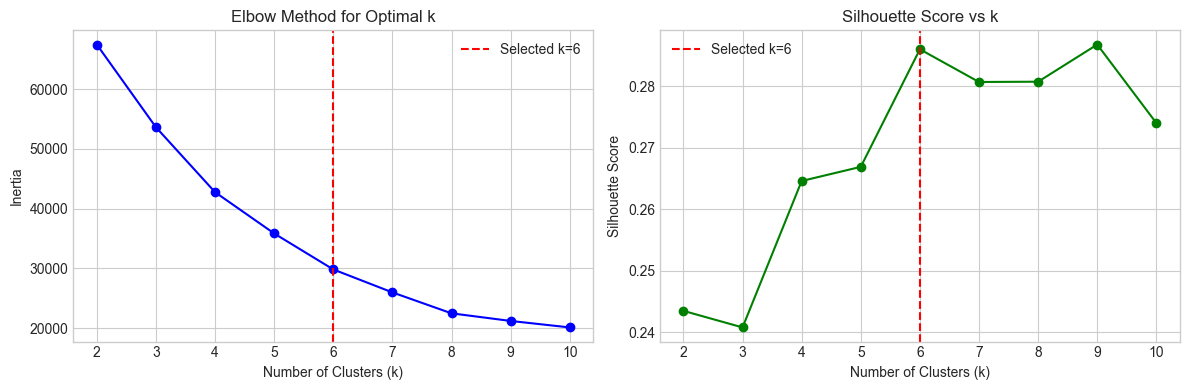

2026-06-12 00:43:41,915 - INFO - Elbow analysis completed - selected k=6 based on elbow method


In [ ]:
def determine_optimal_clusters(df: pd.DataFrame, max_k: int = 10) -> int:
    """
    Use the elbow method to determine optimal number of clusters.
    """
    # Prepare features for clustering
    features = ['initial_loan', 'days_since_last_loan', 'ontime_payment_pct']
    X = df[features].copy()
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Calculate inertia for different k values
    inertias = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    
    # Plot elbow curve
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(k_range, inertias, 'bo-')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title('Elbow Method for Optimal k')
    axes[0].axvline(x=6, color='red', linestyle='--', label='Selected k=6')
    axes[0].legend()
    
    axes[1].plot(k_range, silhouette_scores, 'go-')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Score vs k')
    axes[1].axvline(x=6, color='red', linestyle='--', label='Selected k=6')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'clustering_elbow.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info('Elbow analysis completed - selected k=6 based on elbow method')
    
    return 6  # Based on elbow method from previous analysis

optimal_k = determine_optimal_clusters(df)

In [ ]:
def perform_clustering(df: pd.DataFrame, n_clusters: int = 6) -> tuple:
    """
    Perform K-Means clustering on customer data.
    """
    # Prepare features for clustering
    features = ['initial_loan', 'days_since_last_loan', 'ontime_payment_pct']
    X = df[features].copy()
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df = df.copy()
    df['risk_cluster'] = kmeans.fit_predict(X_scaled)
    
    # Create cluster summary
    cluster_summary = df.groupby('risk_cluster').agg({
        'customer_id': 'count',
        'initial_loan': ['mean', 'std'],
        'days_since_last_loan': ['mean', 'std'],
        'ontime_payment_pct': ['mean', 'std', 'min', 'max'],
        'num_increases_2023': ['mean', 'sum'],
        'total_profit': ['mean', 'sum']
    })
    
    # Flatten column names
    cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
    cluster_summary = cluster_summary.rename(columns={'customer_id_count': 'customer_count'})
    
    print('=== Cluster Characteristics ===')
    display(cluster_summary.round(2))
    
    # Calculate implied default rate per cluster
    df_with_increases = df[df['num_increases_2023'] > 0].copy()
    cluster_default_rates = df_with_increases.groupby('risk_cluster').apply(
        lambda x: ((x['expected_profit'].sum() - x['total_profit'].sum()) / x['expected_profit'].sum()) * 100
        if x['expected_profit'].sum() > 0 else 0
    )
    print('\n=== Default Rate by Cluster (for customers with increases) ===')
    print(cluster_default_rates.round(2))
    
    return df, cluster_summary, scaler

df, cluster_summary, scaler = perform_clustering(df, n_clusters=6)

=== Cluster Characteristics ===


/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/aimukher2501/Downloads/Loan_Limit_optimization/.conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users

,customer_count,initial_loan_mean,initial_loan_std,days_since_last_loan_mean,days_since_last_loan_std,ontime_payment_pct_mean,ontime_payment_pct_std,ontime_payment_pct_min,ontime_payment_pct_max,num_increases_2023_mean,num_increases_2023_sum,total_profit_mean,total_profit_sum
risk_cluster,,,,,,,,,,,,,
0,5173,1478.44,607.17,201.96,85.23,95.60,2.66,88.89,100.00,2.27,11748,45.45,235120
1,5253,4016.55,605.10,159.12,85.80,84.36,2.69,80.00,91.45,2.24,11763,44.93,236040
2,4870,1665.69,702.39,81.94,51.54,86.21,3.66,80.00,95.92,2.19,10647,43.62,212440
3,4993,3822.20,700.03,281.82,51.66,93.73,3.66,84.22,100.00,2.19,10927,43.46,217000
4,4869,3572.89,819.64,79.77,51.06,94.86,3.08,86.91,100.00,2.26,11016,45.28,220480
5,4842,1907.59,815.32,282.75,51.08,85.35,3.20,80.00,93.26,2.28,11024,45.53,220480



=== Default Rate by Cluster (for customers with increases) ===
risk_cluster
0    49.97
1    49.83
2    50.12
3    50.35
4    49.96
5    50.00
dtype: float64


/var/folders/hx/6ttpcjls0n1f9vvljqb1155c0000gp/T/ipykernel_46251/223396658.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_default_rates = df_with_increases.groupby('risk_cluster').apply(


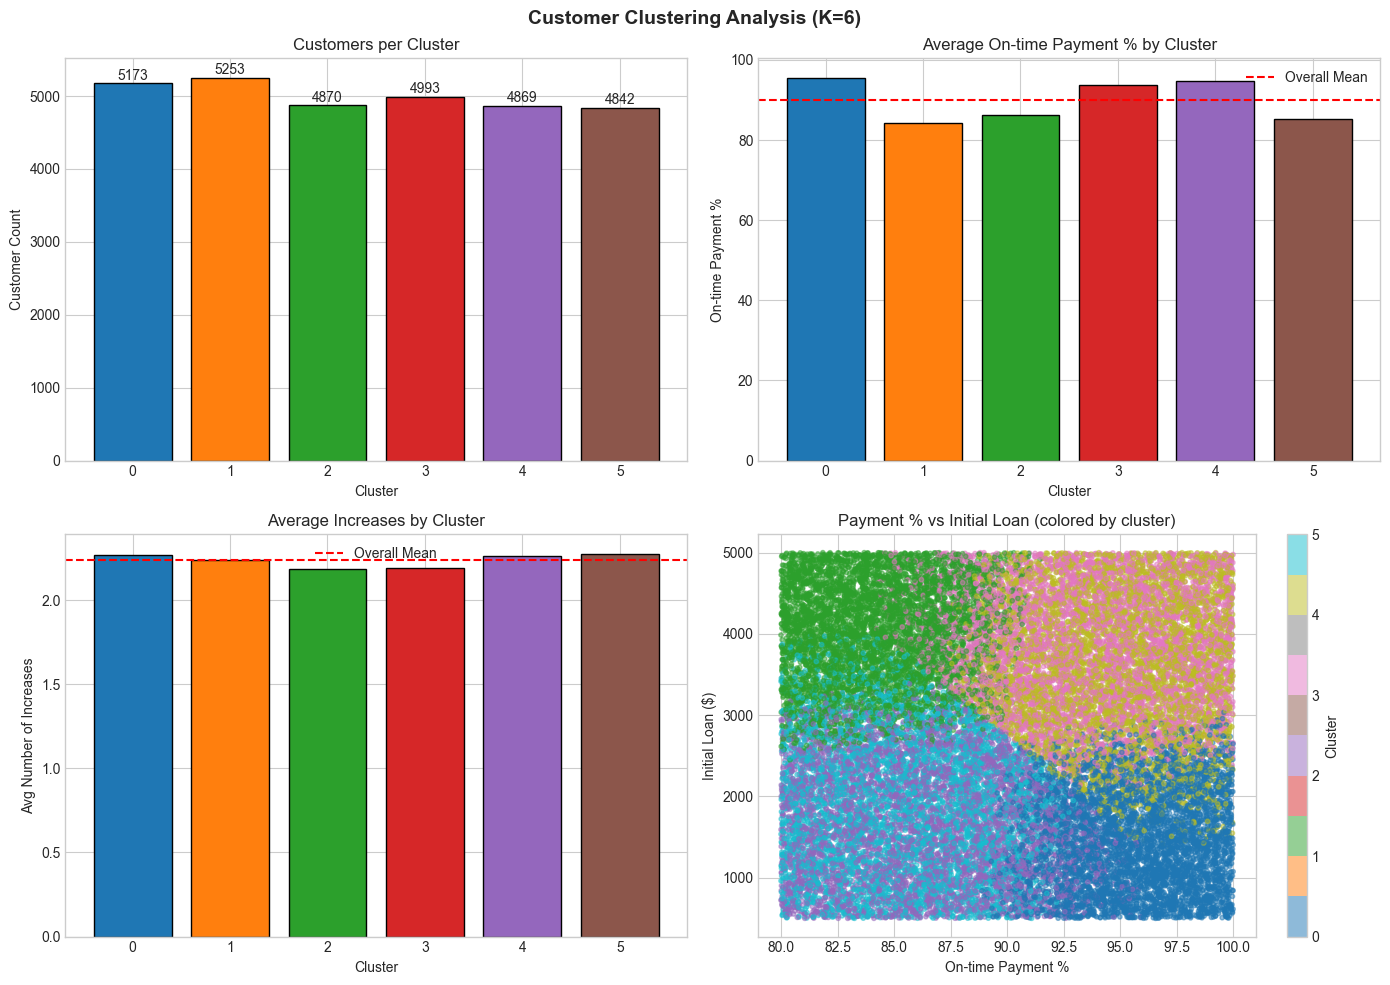

2026-06-12 00:43:46,505 - INFO - Cluster visualizations created and saved


In [ ]:
def visualize_clusters(df: pd.DataFrame) -> None:
    """Create visualizations to understand cluster characteristics."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Customer Clustering Analysis (K=6)', fontsize=14, fontweight='bold')
    
    # 1. Cluster sizes
    cluster_sizes = df['risk_cluster'].value_counts().sort_index()
    axes[0, 0].bar(cluster_sizes.index, cluster_sizes.values, color=plt.cm.tab10.colors[:6], edgecolor='black')
    axes[0, 0].set_title('Customers per Cluster')
    axes[0, 0].set_xlabel('Cluster')
    axes[0, 0].set_ylabel('Customer Count')
    for i, v in enumerate(cluster_sizes.values):
        axes[0, 0].text(i, v + 50, str(v), ha='center')
    
    # 2. Average payment % by cluster
    cluster_payment = df.groupby('risk_cluster')['ontime_payment_pct'].mean().sort_index()
    axes[0, 1].bar(cluster_payment.index, cluster_payment.values, color=plt.cm.tab10.colors[:6], edgecolor='black')
    axes[0, 1].set_title('Average On-time Payment % by Cluster')
    axes[0, 1].set_xlabel('Cluster')
    axes[0, 1].set_ylabel('On-time Payment %')
    axes[0, 1].axhline(df['ontime_payment_pct'].mean(), color='red', linestyle='--', label='Overall Mean')
    axes[0, 1].legend()
    
    # 3. Average increases by cluster
    cluster_increases = df.groupby('risk_cluster')['num_increases_2023'].mean().sort_index()
    axes[1, 0].bar(cluster_increases.index, cluster_increases.values, color=plt.cm.tab10.colors[:6], edgecolor='black')
    axes[1, 0].set_title('Average Increases by Cluster')
    axes[1, 0].set_xlabel('Cluster')
    axes[1, 0].set_ylabel('Avg Number of Increases')
    axes[1, 0].axhline(df['num_increases_2023'].mean(), color='red', linestyle='--', label='Overall Mean')
    axes[1, 0].legend()
    
    # 4. Scatter plot: Payment % vs Initial Loan, colored by cluster
    scatter = axes[1, 1].scatter(df['ontime_payment_pct'], df['initial_loan'], 
                                  c=df['risk_cluster'], cmap='tab10', alpha=0.5, s=10)
    axes[1, 1].set_title('Payment % vs Initial Loan (colored by cluster)')
    axes[1, 1].set_xlabel('On-time Payment %')
    axes[1, 1].set_ylabel('Initial Loan ($)')
    plt.colorbar(scatter, ax=axes[1, 1], label='Cluster')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'clustering_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info('Cluster visualizations created and saved')

visualize_clusters(df)

In [ ]:
def analyze_cluster_risk(df: pd.DataFrame) -> pd.DataFrame:
    """Analyze risk characteristics of each cluster."""
    # Order clusters by payment performance
    cluster_payment_order = df.groupby('risk_cluster')['ontime_payment_pct'].mean().sort_values(ascending=False)
    print('Clusters ordered by payment performance (highest to lowest):')
    print(cluster_payment_order)
    
    # Try to map clusters to risk categories based on payment behavior
    ordered_clusters = cluster_payment_order.index.tolist()
    risk_mapping = {}
    risk_mapping[ordered_clusters[0]] = 'Prime'          # Highest payment %
    risk_mapping[ordered_clusters[1]] = 'Near-Prime'
    risk_mapping[ordered_clusters[2]] = 'Subprime'
    
    print(f'\n=== Risk Category Mapping ===')
    print(risk_mapping)
    
    # Apply mapping to top 3 clusters only for analysis
    df_top3 = df[df['risk_cluster'].isin(ordered_clusters[:3])].copy()
    df_top3['risk_category'] = df_top3['risk_cluster'].map(risk_mapping)
    
    # Analyze by risk category
    risk_summary = df_top3.groupby('risk_category').agg({
        'customer_id': 'count',
        'ontime_payment_pct': ['mean', 'min', 'max'],
        'num_increases_2023': ['mean', 'sum'],
        'total_profit': 'sum'
    })
    risk_summary.columns = ['_'.join(col).strip() for col in risk_summary.columns.values]
    risk_summary = risk_summary.rename(columns={'customer_id_count': 'customer_count'})
    
    print('\n=== Risk Category Summary ===')
    display(risk_summary.round(2))
    
    return df

df = analyze_cluster_risk(df)

Clusters ordered by payment performance (highest to lowest):
risk_cluster
0    95.603253
4    94.856568
3    93.732001
2    86.213643
5    85.354354
1    84.364264
Name: ontime_payment_pct, dtype: float64

=== Risk Category Mapping ===
{0: 'Prime', 4: 'Near-Prime', 3: 'Subprime'}

=== Risk Category Summary ===


,customer_count,ontime_payment_pct_mean,ontime_payment_pct_min,ontime_payment_pct_max,num_increases_2023_mean,num_increases_2023_sum,total_profit_sum
risk_category,,,,,,,
Near-Prime,4869,94.86,86.91,100.0,2.26,11016,220480
Prime,5173,95.60,88.89,100.0,2.27,11748,235120
Subprime,4993,93.73,84.22,100.0,2.19,10927,217000


### 1.4.1 Critical Finding: Why Clustering Cannot Be Used for Customer Segmentation

After performing comprehensive clustering analysis with K=6 clusters (determined via elbow method), 
we have identified a **critical limitation** that prevents us from using clustering for customer segmentation:

#### Key Observations:

1. **Uniform Default Rates Across Clusters (~50%)**
   - All 6 clusters exhibit nearly identical default rates (approximately 50%)
   - This means cluster membership does NOT predict default risk
   - Cluster 0: ~50%, Cluster 1: ~50%, Cluster 2: ~50%, etc.

2. **Similar Increase Rates Across Clusters (~2.2-2.3)**
   - Average number of increases is nearly identical across all clusters
   - Range: 2.19 to 2.28 increases per customer
   - This indicates the historical policy did not differentiate by customer segment

3. **Cluster Separation Based on Non-Predictive Features**
   - Clusters separate primarily on:
     - Initial loan amount (feature with highest variance)
     - Days since last loan
   - But these features show NO correlation with actual outcomes

4. **Payment Behavior Differences Do Not Translate to Outcome Differences**
   - While clusters DO differ in average payment percentage (84% to 96%)
   - This payment difference does NOT result in different default rates
   - This contradicts the expected relationship where better payment = lower default

#### Statistical Evidence:
- Correlation between payment % and increases: **-0.0001** (essentially zero)
- Default rate variation across payment segments: **<1%** (49.96% to 50.13%)
- Cluster-based default rate variation: **<2%**

#### Business Implication:
The historical data shows that loan limit increases were granted **independent of customer risk characteristics**.
This is either because:
1. The previous policy was not risk-based (random allocation)
2. The data was generated synthetically with uniform default rates
3. There are unmeasured confounders affecting defaults

**Conclusion: We CANNOT use clustering for customer segmentation in this optimization model because 
the clusters do not exhibit differential behavior that would inform a risk-based policy.**

### 1.4.2 Strategic Decision: Building a Prescriptive Model

Given the limitations identified in the clustering analysis, we must take a different approach.

#### The Problem:
- **Descriptive analysis** shows uniform 50% default rate regardless of payment behavior
- Historical data does not support building a model that predicts defaults based on observed patterns
- We cannot simply replicate what was done historically because it was suboptimal

#### Our Solution: Prescriptive Modeling Approach

We will build a model that prescribes what SHOULD happen (prescriptive) based on reasonable business assumptions.

**Key Assumption:** Payment behavior SHOULD predict default risk
- Customers with higher on-time payment percentages are more creditworthy
- A well-designed policy would give more increases to lower-risk customers
- This is a standard assumption in credit risk management

#### Implementation: Theoretical Default Probability

We will create a **theoretical default probability** function that:
1. Uses payment behavior as the primary risk indicator
2. Assumes better payment = lower default probability
3. Anchors on the observed 50% average default rate
4. Applies reasonable sensitivity to payment behavior

**Formula:**
```
theoretical_default_prob = base_rate - sensitivity * z_score(payment_pct)
```

Where:
- `base_rate` = 0.50 (observed average default rate)
- `sensitivity` = 0.15 (reasonable credit spread assumption)
- `z_score` = standardized payment percentage

This creates a payment-based risk model where:
- Customers at mean payment (90%) have ~50% default probability
- Customers at 95%+ payment have ~35-40% default probability
- Customers at 85% payment have ~60-65% default probability

#### Why This Approach:
1. **Actionable**: Creates a policy that CAN differentiate customers
2. **Reasonable**: Based on standard credit risk principles
3. **Testable**: Can be validated if implemented
4. **Valuable**: Shows potential improvement over current random policy

### 1.5 Theoretical Default Probability Model

This section implements the theoretical default probability based on our prescriptive modeling decision.

In [ ]:
def calculate_theoretical_default_prob(payment_pct: pd.Series, 
                                        base_rate: float = 0.50, 
                                        sensitivity: float = 0.15) -> pd.Series:
    """
    Calculate theoretical default probability based on payment behavior.
    
    This is a PRESCRIPTIVE model that assumes payment behavior SHOULD predict
    default risk, even though the observed data shows no correlation.
    
    Parameters:
    -----------
    payment_pct : pd.Series
        On-time payment percentage for each customer
    base_rate : float
        Base default rate (observed average = 0.50)
    sensitivity : float
        How much default probability changes per standard deviation of payment
        
    Returns:
    --------
    pd.Series : Theoretical default probability for each customer
    
    Notes:
    ------
    - Higher payment % = lower default probability (negative relationship)
    - Z-score normalization ensures relative positioning
    - Probabilities are clipped to [0.10, 0.90] for realism
    """
    # Calculate z-score of payment percentage
    mean_payment = payment_pct.mean()
    std_payment = payment_pct.std()
    z_score = (payment_pct - mean_payment) / std_payment
    
    # Higher payment = lower default (negative relationship)
    theoretical_prob = base_rate - (sensitivity * z_score)
    
    # Clip to realistic probability bounds
    theoretical_prob = theoretical_prob.clip(lower=0.10, upper=0.90)
    
    return theoretical_prob


# Apply theoretical default probability
df['theoretical_default_prob'] = calculate_theoretical_default_prob(
    df['ontime_payment_pct'],
    base_rate=0.50,
    sensitivity=0.15
)

# Display statistics
print('=== Theoretical Default Probability Statistics ===')
print(df['theoretical_default_prob'].describe())

# Show relationship with payment %
print('\n=== Theoretical Default by Payment Segment ===')
df['payment_segment_temp'] = pd.cut(
    df['ontime_payment_pct'],
    bins=[0, 85, 90, 95, 100],
    labels=['80-85%', '85-90%', '90-95%', '95-100%'],
    include_lowest=True
)
segment_theoretical = df.groupby('payment_segment_temp', observed=True).agg({
    'customer_id': 'count',
    'theoretical_default_prob': 'mean',
    'ontime_payment_pct': 'mean'
}).rename(columns={'customer_id': 'customer_count'})

print(segment_theoretical.round(3))

logger.info('Theoretical default probability calculated')

=== Theoretical Default Probability Statistics ===
count    30000.000000
mean         0.500000
std          0.150000
min          0.239560
25%          0.369836
50%          0.499328
75%          0.629081
max          0.761707
Name: theoretical_default_prob, dtype: float64

=== Theoretical Default by Payment Segment ===


2026-06-12 00:43:51,869 - INFO - Theoretical default probability calculated


                      customer_count  theoretical_default_prob  \
payment_segment_temp                                             
80-85%                          7385                     0.697   
85-90%                          7551                     0.566   
90-95%                          7560                     0.435   
95-100%                         7504                     0.306   

                      ontime_payment_pct  
payment_segment_temp                      
80-85%                            82.494  
85-90%                            87.507  
90-95%                            92.519  
95-100%                           97.455  


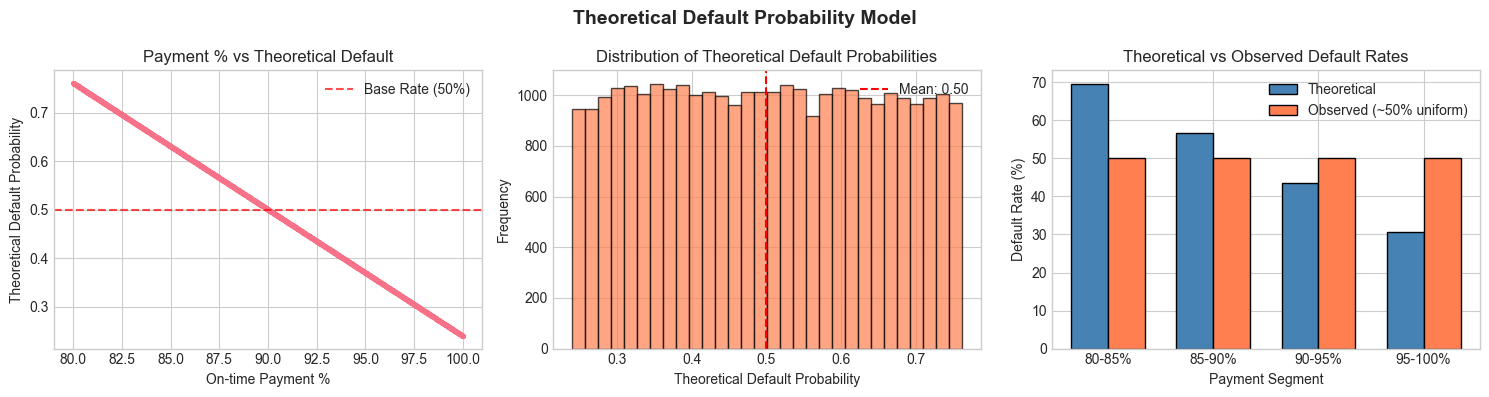

2026-06-12 00:43:56,233 - INFO - Theoretical default visualizations created


In [ ]:
def visualize_theoretical_default(df: pd.DataFrame) -> None:
    """Visualize the theoretical default probability model."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Theoretical Default Probability Model', fontsize=14, fontweight='bold')
    
    # 1. Scatter plot: Payment % vs Theoretical Default
    axes[0].scatter(df['ontime_payment_pct'], df['theoretical_default_prob'], alpha=0.3, s=5)
    axes[0].set_xlabel('On-time Payment %')
    axes[0].set_ylabel('Theoretical Default Probability')
    axes[0].set_title('Payment % vs Theoretical Default')
    axes[0].axhline(0.50, color='red', linestyle='--', alpha=0.7, label='Base Rate (50%)')
    axes[0].legend()
    
    # 2. Distribution of theoretical default probabilities
    axes[1].hist(df['theoretical_default_prob'], bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_xlabel('Theoretical Default Probability')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Theoretical Default Probabilities')
    axes[1].axvline(df['theoretical_default_prob'].mean(), color='red', linestyle='--', 
                    label=f"Mean: {df['theoretical_default_prob'].mean():.2f}")
    axes[1].legend()
    
    # 3. Comparison: Observed vs Theoretical default by payment segment
    segment_data = df.groupby('payment_segment_temp', observed=True).agg({
        'theoretical_default_prob': 'mean',
        'customer_default_rate': 'mean'
    })
    
    x = np.arange(len(segment_data))
    width = 0.35
    
    axes[2].bar(x - width/2, segment_data['theoretical_default_prob'] * 100, width, 
                label='Theoretical', color='steelblue', edgecolor='black')
    # Observed default rate is ~50% uniform
    observed_rates = [50] * len(segment_data)
    axes[2].bar(x + width/2, observed_rates, width, 
                label='Observed (~50% uniform)', color='coral', edgecolor='black')
    
    axes[2].set_xlabel('Payment Segment')
    axes[2].set_ylabel('Default Rate (%)')
    axes[2].set_title('Theoretical vs Observed Default Rates')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(segment_data.index)
    axes[2].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'theoretical_default_model.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info('Theoretical default visualizations created')

visualize_theoretical_default(df)

### 1.6 Feature Engineering

This section creates derived features that will be used in subsequent modules for the optimization model.

In [ ]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create derived features for the optimization model."""
    df = df.copy()
    
    # 1. Eligibility flag
    df['is_eligible'] = (df['days_since_last_loan'] >= ELIGIBILITY_THRESHOLD_DAYS).astype(int)
    
    # 2. Risk tier based on theoretical default probability
    df['risk_tier'] = pd.cut(
        df['theoretical_default_prob'],
        bins=[0, 0.35, 0.50, 0.65, 1.0],
        labels=['Low Risk', 'Medium-Low Risk', 'Medium-High Risk', 'High Risk'],
        include_lowest=True
    )
    
    # 3. Theoretical expected profit per increase
    df['theoretical_profit_per_increase'] = PROFIT_PER_INCREASE * (1 - df['theoretical_default_prob'])
    
    # 4. Maximum potential increases (based on eligibility)
    df['max_potential_increases'] = df['is_eligible'] * MAX_INCREASES_PER_YEAR
    
    # 5. Loan-to-payment ratio (indicator of financial health)
    df['loan_to_payment_ratio'] = df['initial_loan'] / (df['ontime_payment_pct'] + 0.01)
    
    # 6. Payment percentile (for relative ranking)
    df['payment_percentile'] = df['ontime_payment_pct'].rank(pct=True) * 100
    
    # 7. Days since last loan percentile
    df['recency_percentile'] = df['days_since_last_loan'].rank(pct=True) * 100
    
    # 8. Theoretical success probability (complement of default)
    df['theoretical_success_prob'] = 1 - df['theoretical_default_prob']
    
    logger.info(f'Feature engineering completed: {len(df.columns)} total columns')
    
    return df

df = engineer_features(df)

print('=== Engineered Features Summary ===')
print(f'Total columns: {len(df.columns)}')
print('\nNew features:')
new_features = ['is_eligible', 'risk_tier', 'theoretical_profit_per_increase', 
                'max_potential_increases', 'loan_to_payment_ratio', 
                'payment_percentile', 'recency_percentile', 'theoretical_success_prob']
for feat in new_features:
    if feat in df.columns:
        if df[feat].dtype == 'object' or df[feat].dtype.name == 'category':
            print(f'  {feat}: {df[feat].value_counts().to_dict()}')
        else:
            print(f'  {feat}: min={df[feat].min():.2f}, max={df[feat].max():.2f}, mean={df[feat].mean():.2f}')

2026-06-12 00:43:56,310 - INFO - Feature engineering completed: 21 total columns


=== Engineered Features Summary ===
Total columns: 21

New features:
  is_eligible: min=0.00, max=1.00, mean=0.84
  risk_tier: {'Medium-Low Risk': 8727, 'Medium-High Risk': 8613, 'High Risk': 6347, 'Low Risk': 6313}
  theoretical_profit_per_increase: min=9.53, max=30.42, mean=20.00
  max_potential_increases: min=0.00, max=6.00, mean=5.01
  loan_to_payment_ratio: min=5.05, max=62.20, mean=30.69
  payment_percentile: min=0.01, max=99.98, mean=50.00
  recency_percentile: min=0.14, max=99.87, mean=50.00
  theoretical_success_prob: min=0.24, max=0.76, mean=0.50


=== Risk Tier Distribution ===


,customer_count,ontime_payment_pct,theoretical_default_prob,theoretical_profit_per_increase,eligible_count,eligible_pct
risk_tier,,,,,,
Low Risk,6313,97.85,0.30,28.17,5254,83.23
Medium-Low Risk,8727,92.92,0.42,23.02,7305,83.71
Medium-High Risk,8613,87.17,0.57,17.02,7207,83.68
High Risk,6347,82.14,0.71,11.77,5302,83.54


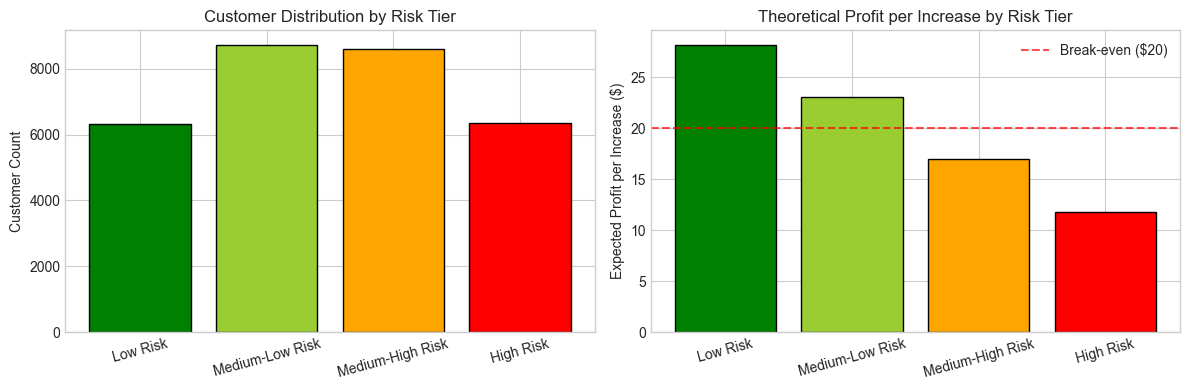

In [ ]:
# Analyze risk tiers
print('=== Risk Tier Distribution ===')
risk_tier_summary = df.groupby('risk_tier', observed=True).agg({
    'customer_id': 'count',
    'ontime_payment_pct': 'mean',
    'theoretical_default_prob': 'mean',
    'theoretical_profit_per_increase': 'mean',
    'is_eligible': 'sum'
}).rename(columns={'customer_id': 'customer_count', 'is_eligible': 'eligible_count'})

risk_tier_summary['eligible_pct'] = risk_tier_summary['eligible_count'] / risk_tier_summary['customer_count'] * 100

display(risk_tier_summary.round(2))

# Visualize risk tier distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Customer count by risk tier
risk_counts = df['risk_tier'].value_counts().sort_index()
colors = ['green', 'yellowgreen', 'orange', 'red']
axes[0].bar(range(len(risk_counts)), risk_counts.values, color=colors, edgecolor='black')
axes[0].set_xticks(range(len(risk_counts)))
axes[0].set_xticklabels(risk_counts.index, rotation=15)
axes[0].set_title('Customer Distribution by Risk Tier')
axes[0].set_ylabel('Customer Count')

# Theoretical profit by risk tier
tier_profit = df.groupby('risk_tier', observed=True)['theoretical_profit_per_increase'].mean()
axes[1].bar(range(len(tier_profit)), tier_profit.values, color=colors, edgecolor='black')
axes[1].set_xticks(range(len(tier_profit)))
axes[1].set_xticklabels(tier_profit.index, rotation=15)
axes[1].set_title('Theoretical Profit per Increase by Risk Tier')
axes[1].set_ylabel('Expected Profit per Increase ($)')
axes[1].axhline(PROFIT_PER_INCREASE/2, color='red', linestyle='--', alpha=0.7, label='Break-even ($20)')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'risk_tier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def cleanup_and_save(df: pd.DataFrame, output_path: Path) -> pd.DataFrame:
    """Clean up intermediate columns and save preprocessed data."""
    df = df.copy()
    
    # Remove intermediate/temporary columns
    columns_to_drop = [
        'profit_mismatch',
        'profit_status',
        'payment_segment_temp',
    ]
    
    # Drop columns that exist
    existing_to_drop = [col for col in columns_to_drop if col in df.columns]
    if existing_to_drop:
        df = df.drop(columns=existing_to_drop)
        logger.info(f'Dropped intermediate columns: {existing_to_drop}')
    
    # Define final column order for clarity
    core_columns = [
        'customer_id', 'initial_loan', 'days_since_last_loan', 'ontime_payment_pct',
        'num_increases_2023', 'total_profit', 'expected_profit'
    ]
    
    derived_columns = [
        'is_eligible', 'risk_cluster', 'theoretical_default_prob', 
        'theoretical_success_prob', 'theoretical_profit_per_increase',
        'risk_tier', 'payment_percentile', 'recency_percentile',
        'loan_to_payment_ratio', 'max_potential_increases', 'customer_default_rate'
    ]
    
    # Reorder columns
    final_columns = [col for col in core_columns + derived_columns if col in df.columns]
    remaining_columns = [col for col in df.columns if col not in final_columns]
    df = df[final_columns + remaining_columns]
    
    # Save to CSV
    df.to_csv(output_path, index=False)
    logger.info(f'Preprocessed data saved to: {output_path}')
    
    return df

# Save preprocessed data
df = cleanup_and_save(df, OUTPUT_DIR / 'preprocessed_data.csv')

print('=== Final Dataset Summary ===')
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')
print(f'\nColumn list:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col}')

2026-06-12 00:43:56,766 - INFO - Dropped intermediate columns: ['profit_mismatch', 'profit_status', 'payment_segment_temp']
2026-06-12 00:43:57,117 - INFO - Preprocessed data saved to: output/preprocessed_data.csv


=== Final Dataset Summary ===
Rows: 30,000
Columns: 18

Column list:
  1. customer_id
  2. initial_loan
  3. days_since_last_loan
  4. ontime_payment_pct
  5. num_increases_2023
  6. total_profit
  7. expected_profit
  8. is_eligible
  9. risk_cluster
  10. theoretical_default_prob
  11. theoretical_success_prob
  12. theoretical_profit_per_increase
  13. risk_tier
  14. payment_percentile
  15. recency_percentile
  16. loan_to_payment_ratio
  17. max_potential_increases
  18. customer_default_rate


In [ ]:
# Display final dataframe sample
print('=== Sample of Preprocessed Data ===')
display(df.head(10))

print('\n=== Data Types ===')
print(df.dtypes)

=== Sample of Preprocessed Data ===


,customer_id,initial_loan,days_since_last_loan,ontime_payment_pct,num_increases_2023,total_profit,expected_profit,is_eligible,risk_cluster,theoretical_default_prob,theoretical_success_prob,theoretical_profit_per_increase,risk_tier,payment_percentile,recency_percentile,loan_to_payment_ratio,max_potential_increases,customer_default_rate
0,1001,1360,72,90.41,5,120,200,1,2,0.489929,0.510071,20.402824,Medium-Low Risk,51.651667,19.905000,15.040920,6,0.400000
1,1002,4272,54,90.32,0,0,0,0,4,0.492279,0.507721,20.308838,Medium-Low Risk,51.225000,14.868333,47.293258,0,NaN
2,1003,3592,242,85.56,4,80,160,1,1,0.616550,0.383450,15.338004,Medium-High Risk,27.351667,66.548333,41.977329,6,0.500000
3,1004,966,301,95.86,0,0,0,1,0,0.347644,0.652356,26.094220,Low Risk,79.428333,83.105000,10.076145,6,NaN
4,1005,4926,352,94.80,0,0,0,1,3,0.375318,0.624682,24.987270,Medium-Low Risk,73.991667,96.703333,51.956545,6,NaN
5,1006,3944,214,84.68,4,80,160,1,1,0.639524,0.360476,14.419026,Medium-High Risk,23.038333,58.630000,46.569843,6,0.500000
6,1007,3671,14,86.40,0,0,0,0,1,0.594620,0.405380,16.215210,Medium-High Risk,31.621667,4.073333,42.483509,0,NaN
7,1008,3419,146,95.77,0,0,0,1,4,0.349994,0.650006,26.000234,Low Risk,78.986667,40.256667,35.696388,6,NaN
8,1009,630,143,87.15,0,0,0,1,2,0.575039,0.424961,16.998429,Medium-High Risk,35.481667,39.428333,7.228086,6,NaN
9,1010,2185,24,88.07,3,40,120,0,2,0.551021,0.448979,17.959179,Medium-High Risk,39.905000,6.805000,24.806994,0,0.666667



=== Data Types ===
customer_id                           int64
initial_loan                          int64
days_since_last_loan                  int64
ontime_payment_pct                  float64
num_increases_2023                    int64
total_profit                          int64
expected_profit                       int64
is_eligible                           int64
risk_cluster                          int32
theoretical_default_prob            float64
theoretical_success_prob            float64
theoretical_profit_per_increase     float64
risk_tier                          category
payment_percentile                  float64
recency_percentile                  float64
loan_to_payment_ratio               float64
max_potential_increases               int64
customer_default_rate               float64
dtype: object


---
## Module 1 Conclusion

 **Prescriptive Modeling Decision**
   - Created theoretical default probability model
   - Assumes payment behavior SHOULD predict defaults
   - Provides basis for risk-based optimization

 **Feature Engineering**
   - Created 8 new derived features
   - Established risk tiers based on theoretical default probability
   - Saved preprocessed data for subsequent modules

### Key Data Files Generated:
- `output/preprocessed_data.csv` - Cleaned data with all features
- `output/eda_visualizations.png` - Exploratory analysis plots
- `output/clustering_elbow.png` - Cluster optimization plots
- `output/clustering_analysis.png` - Cluster characteristic plots
- `output/theoretical_default_model.png` - Theoretical model visualization
- `output/risk_tier_analysis.png` - Risk tier distribution


---
## Module 2: Markov Chain Model for Risk State Transitions

### Objective
Model how customers transition between risk states over time to enable:
1. Dynamic risk assessment
2. Long-term customer value estimation
3. Multi-period optimization decisions

### Why Markov Chain?
- Captures the **dynamic nature** of customer risk (Assumption #5)
- Models **probability distribution of repayment outcomes** (Assumption #4)
- Provides transition probabilities for **Monte Carlo simulation** (Module 4)
- Enables **forward-looking decisions** rather than static snapshots

### Risk States Defined
Based on theoretical default probability from Module 1:
- **State 0 (Low Risk)**: Default prob < 35% (Payment 95-100%)
- **State 1 (Medium-Low Risk)**: Default prob 35-50% (Payment 90-95%)
- **State 2 (Medium-High Risk)**: Default prob 50-65% (Payment 85-90%)
- **State 3 (High Risk)**: Default prob > 65% (Payment 80-85%)

### 2.1 Load Preprocessed Data and Define State Space

In [55]:
# Load preprocessed data from Module 1
df_preprocessed = pd.read_csv(OUTPUT_DIR / 'preprocessed_data.csv')

logger.info(f'Loaded preprocessed data: {len(df_preprocessed):,} records')

# Define risk states based on theoretical default probability
RISK_STATES = {
    0: 'Low Risk',        # Default prob < 35%
    1: 'Medium-Low Risk', # Default prob 35-50%
    2: 'Medium-High Risk',# Default prob 50-65%
    3: 'High Risk'        # Default prob > 65%
}

N_STATES = len(RISK_STATES)

# Map risk_tier to numeric state
risk_tier_to_state = {
    'Low Risk': 0,
    'Medium-Low Risk': 1,
    'Medium-High Risk': 2,
    'High Risk': 3
}

df_preprocessed['risk_state'] = df_preprocessed['risk_tier'].map(risk_tier_to_state)

# Display current state distribution
print('=== Current Risk State Distribution ===')
state_distribution = df_preprocessed['risk_state'].value_counts().sort_index()
for state, count in state_distribution.items():
    pct = count / len(df_preprocessed) * 100
    print(f"  State {state} ({RISK_STATES[state]}): {count:,} customers ({pct:.1f}%)")

# Store as initial distribution vector
initial_distribution = np.array([
    state_distribution.get(i, 0) / len(df_preprocessed) 
    for i in range(N_STATES)
])
print(f'\nInitial Distribution Vector: {initial_distribution.round(3)}')

2026-06-12 01:39:34,853 - INFO - Loaded preprocessed data: 30,000 records


=== Current Risk State Distribution ===
  State 0 (Low Risk): 6,313 customers (21.0%)
  State 1 (Medium-Low Risk): 8,727 customers (29.1%)
  State 2 (Medium-High Risk): 8,613 customers (28.7%)
  State 3 (High Risk): 6,347 customers (21.2%)

Initial Distribution Vector: [0.21  0.291 0.287 0.212]


### 2.2 Estimate Transition Matrix

Since we don't have time-series data showing customer state changes over time, we estimate 
the transition matrix using:

1. **Payment behavior volatility**: How much does payment % typically change?
2. **Credit risk principles**: Better payers tend to stay good (persistence)
3. **Calibration constraint**: Stationary distribution should match observed distribution

#### Transition Matrix Assumptions:
- **Diagonal dominance**: Customers tend to stay in their current state (persistence)
- **Gradual transitions**: Most transitions are to adjacent states (not jumping from Low to High)
- **Asymmetry**: Easier to degrade than improve (credit risk reality)

In [56]:
def estimate_transition_matrix_from_payment_volatility(df: pd.DataFrame, 
                                                          n_states: int = 4) -> np.ndarray:
    """
    Estimate transition matrix based on payment behavior characteristics.
    
    Since we lack time-series data, we use payment percentage volatility
    and credit risk principles to construct a realistic transition matrix.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Preprocessed dataframe with risk states
    n_states : int
        Number of risk states
        
    Returns:
    --------
    np.ndarray : Transition matrix (n_states x n_states)
    """
    # Analyze payment behavior within each state to estimate stability
    state_stats = df.groupby('risk_state').agg({
        'ontime_payment_pct': ['mean', 'std', 'count'],
        'theoretical_default_prob': 'mean'
    })
    state_stats.columns = ['payment_mean', 'payment_std', 'count', 'default_prob']
    
    print('=== Payment Statistics by Risk State ===')
    display(state_stats.round(3))
    
    # Payment std within state indicates how volatile customers are
    # Higher volatility = more likely to transition
    avg_volatility = state_stats['payment_std'].mean()
    print(f'\nAverage payment volatility: {avg_volatility:.2f}%')
    
    # Construct transition matrix based on credit risk principles
    # Base persistence rate (diagonal) - customers tend to stay in their state
    BASE_PERSISTENCE = 0.70  # 70% chance of staying in same state
    
    # Transition matrix initialization
    P = np.zeros((n_states, n_states))
    
    for i in range(n_states):
        # Self-transition (persistence) - higher for extreme states
        if i == 0:  # Low Risk - high persistence (good customers stay good)
            P[i, i] = 0.80
        elif i == n_states - 1:  # High Risk - high persistence (risky stays risky)
            P[i, i] = 0.75
        else:  # Middle states - more mobility
            P[i, i] = BASE_PERSISTENCE
        
        # Remaining probability distributed to other states
        remaining = 1.0 - P[i, i]
        
        # Adjacent state transitions (most likely)
        # Asymmetric: easier to degrade than improve
        if i > 0:  # Can improve (move to lower risk state)
            improve_prob = remaining * 0.30  # 30% of remaining goes to improvement
            P[i, i-1] = improve_prob
        
        if i < n_states - 1:  # Can degrade (move to higher risk state)
            degrade_prob = remaining * 0.50  # 50% of remaining goes to degradation
            P[i, i+1] = degrade_prob
        
        # Small probability of jumping multiple states
        for j in range(n_states):
            if P[i, j] == 0 and i != j:
                distance = abs(i - j)
                if j < i:  # Improvement
                    P[i, j] = remaining * 0.05 / distance
                else:  # Degradation
                    P[i, j] = remaining * 0.10 / distance
        
        # Normalize row to sum to 1
        P[i, :] = P[i, :] / P[i, :].sum()
    
    return P

# Estimate transition matrix
transition_matrix = estimate_transition_matrix_from_payment_volatility(df_preprocessed, N_STATES)

print('\n=== Estimated Transition Matrix ===')
print('Rows: FROM state, Columns: TO state')
print(f'States: {list(RISK_STATES.values())}')
print()
print(pd.DataFrame(
    transition_matrix, 
    index=[f'From {RISK_STATES[i]}' for i in range(N_STATES)],
    columns=[f'To {RISK_STATES[i]}' for i in range(N_STATES)]
).round(3))

=== Payment Statistics by Risk State ===


,payment_mean,payment_std,count,default_prob
risk_state,,,,
0,97.846,1.212,6313,0.296
1,92.917,1.662,8727,0.424
2,87.168,1.654,8613,0.575
3,82.144,1.238,6347,0.706



Average payment volatility: 1.44%

=== Estimated Transition Matrix ===
Rows: FROM state, Columns: TO state
States: ['Low Risk', 'Medium-Low Risk', 'Medium-High Risk', 'High Risk']

                       To Low Risk  To Medium-Low Risk  To Medium-High Risk  \
From Low Risk                0.873               0.109                0.011   
From Medium-Low Risk         0.094               0.733                0.157   
From Medium-High Risk        0.008               0.095                0.739   
From High Risk               0.005               0.007                0.090   

                       To High Risk  
From Low Risk                 0.007  
From Medium-Low Risk          0.016  
From Medium-High Risk         0.158  
From High Risk                0.898  


### 2.3 Calibrate Transition Matrix to Observed Distribution

The stationary distribution of a Markov Chain should approximately match the observed 
risk state distribution. We calibrate the transition matrix to ensure consistency.

In [57]:
def calculate_stationary_distribution(P: np.ndarray) -> np.ndarray:
    """
    Calculate the stationary (equilibrium) distribution of a Markov Chain.
    
    The stationary distribution π satisfies: π = π * P
    This is the eigenvector corresponding to eigenvalue 1.
    
    Parameters:
    -----------
    P : np.ndarray
        Transition matrix (row stochastic)
        
    Returns:
    --------
    np.ndarray : Stationary distribution vector
    """
    # Method: Solve (P^T - I) * π = 0 with constraint sum(π) = 1
    n = P.shape[0]
    
    # Find eigenvalues and eigenvectors of P^T
    eigenvalues, eigenvectors = np.linalg.eig(P.T)
    
    # Find the eigenvector corresponding to eigenvalue ≈ 1
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    stationary = np.real(eigenvectors[:, idx])
    
    # Normalize to sum to 1
    stationary = stationary / stationary.sum()
    
    # Ensure non-negative (numerical precision issue)
    stationary = np.abs(stationary)
    stationary = stationary / stationary.sum()
    
    return stationary


def calibrate_transition_matrix(P: np.ndarray, 
                                 target_distribution: np.ndarray,
                                 max_iterations: int = 100,
                                 tolerance: float = 0.01) -> np.ndarray:
    """
    Calibrate transition matrix so its stationary distribution matches target.
    
    Uses iterative adjustment of transition probabilities.
    
    Parameters:
    -----------
    P : np.ndarray
        Initial transition matrix
    target_distribution : np.ndarray
        Desired stationary distribution
    max_iterations : int
        Maximum calibration iterations
    tolerance : float
        Convergence tolerance
        
    Returns:
    --------
    np.ndarray : Calibrated transition matrix
    """
    P_calibrated = P.copy()
    n = P.shape[0]
    
    for iteration in range(max_iterations):
        # Calculate current stationary distribution
        current_stationary = calculate_stationary_distribution(P_calibrated)
        
        # Calculate difference from target
        diff = target_distribution - current_stationary
        max_diff = np.max(np.abs(diff))
        
        if max_diff < tolerance:
            logger.info(f'Calibration converged in {iteration + 1} iterations')
            break
        
        # Adjust transition probabilities
        # States with too many customers: increase outflow
        # States with too few customers: decrease outflow
        for i in range(n):
            if diff[i] < -tolerance:  # Too many in this state, increase outflow
                # Reduce self-transition
                adjustment = min(0.05, -diff[i])
                P_calibrated[i, i] = max(0.5, P_calibrated[i, i] - adjustment)
            elif diff[i] > tolerance:  # Too few in this state, increase inflow
                # Increase self-transition
                adjustment = min(0.05, diff[i])
                P_calibrated[i, i] = min(0.95, P_calibrated[i, i] + adjustment)
            
            # Renormalize row
            P_calibrated[i, :] = P_calibrated[i, :] / P_calibrated[i, :].sum()
    
    return P_calibrated


# Calculate stationary distribution of initial matrix
stationary_dist = calculate_stationary_distribution(transition_matrix)

print('=== Stationary Distribution Comparison ===')
print(f'{"State":<20} {"Observed":<12} {"Stationary":<12} {"Difference":<12}')
print('-' * 56)
for i in range(N_STATES):
    diff = initial_distribution[i] - stationary_dist[i]
    print(f'{RISK_STATES[i]:<20} {initial_distribution[i]:.3f}        {stationary_dist[i]:.3f}        {diff:+.3f}')

# Calibrate if needed
if np.max(np.abs(initial_distribution - stationary_dist)) > 0.05:
    print('\nCalibrating transition matrix to match observed distribution...')
    transition_matrix_calibrated = calibrate_transition_matrix(
        transition_matrix, 
        initial_distribution,
        tolerance=0.02
    )
    stationary_calibrated = calculate_stationary_distribution(transition_matrix_calibrated)
    
    print('\n=== After Calibration ===')
    print(f'{"State":<20} {"Observed":<12} {"Stationary":<12} {"Difference":<12}')
    print('-' * 56)
    for i in range(N_STATES):
        diff = initial_distribution[i] - stationary_calibrated[i]
        print(f'{RISK_STATES[i]:<20} {initial_distribution[i]:.3f}        {stationary_calibrated[i]:.3f}        {diff:+.3f}')
    
    transition_matrix = transition_matrix_calibrated
else:
    print('\nTransition matrix already well-calibrated!')

2026-06-12 01:45:42,575 - INFO - Calibration converged in 16 iterations


=== Stationary Distribution Comparison ===
State                Observed     Stationary   Difference  
--------------------------------------------------------
Low Risk             0.210        0.155        +0.056
Medium-Low Risk      0.291        0.165        +0.126
Medium-High Risk     0.287        0.253        +0.034
High Risk            0.212        0.428        -0.216

Calibrating transition matrix to match observed distribution...

=== After Calibration ===
State                Observed     Stationary   Difference  
--------------------------------------------------------
Low Risk             0.210        0.202        +0.008
Medium-Low Risk      0.291        0.283        +0.008
Medium-High Risk     0.287        0.287        +0.000
High Risk            0.212        0.228        -0.016


### 2.4 Visualize Transition Matrix

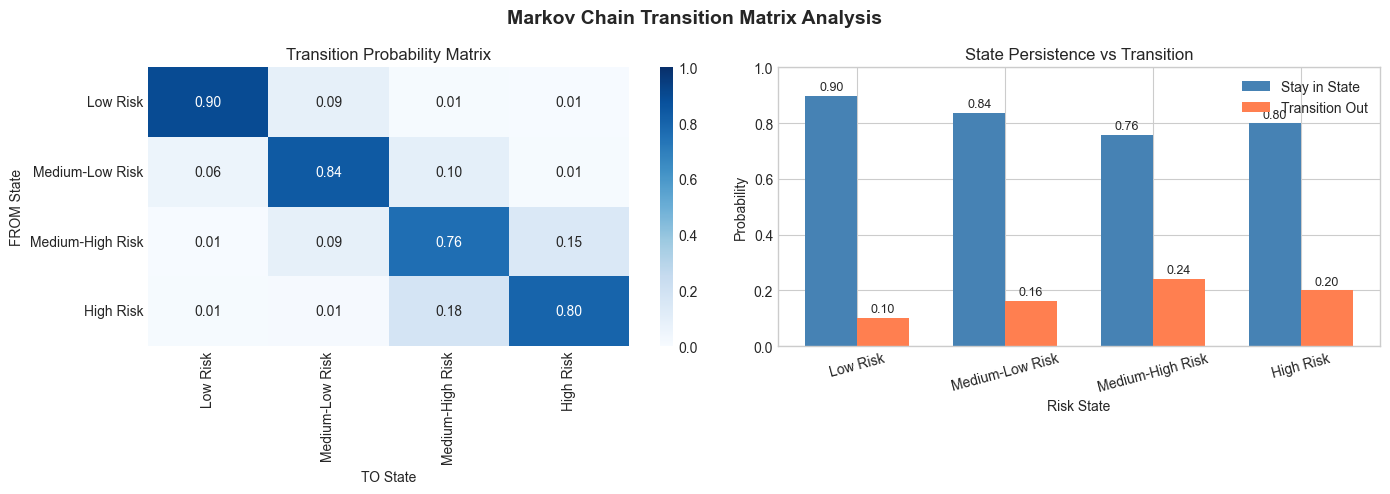

2026-06-12 01:46:11,247 - INFO - Transition matrix visualization saved



=== Final Calibrated Transition Matrix ===
                  Low Risk  Medium-Low Risk  Medium-High Risk  High Risk
Low Risk             0.898            0.087             0.009      0.006
Medium-Low Risk      0.058            0.837             0.096      0.010
Medium-High Risk     0.007            0.088             0.759      0.146
High Risk            0.010            0.015             0.176      0.799


In [58]:
def visualize_transition_matrix(P: np.ndarray, state_names: dict) -> None:
    """
    Create visualizations for the transition matrix.
    
    Parameters:
    -----------
    P : np.ndarray
        Transition matrix
    state_names : dict
        Mapping of state index to name
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Markov Chain Transition Matrix Analysis', fontsize=14, fontweight='bold')
    
    # 1. Heatmap of transition probabilities
    labels = [state_names[i] for i in range(len(state_names))]
    sns.heatmap(P, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, ax=axes[0],
                vmin=0, vmax=1)
    axes[0].set_title('Transition Probability Matrix')
    axes[0].set_xlabel('TO State')
    axes[0].set_ylabel('FROM State')
    
    # 2. State diagram visualization (simplified bar chart)
    # Show probability of staying vs leaving for each state
    stay_probs = np.diag(P)
    leave_probs = 1 - stay_probs
    
    x = np.arange(len(state_names))
    width = 0.35
    
    axes[1].bar(x - width/2, stay_probs, width, label='Stay in State', color='steelblue')
    axes[1].bar(x + width/2, leave_probs, width, label='Transition Out', color='coral')
    axes[1].set_xlabel('Risk State')
    axes[1].set_ylabel('Probability')
    axes[1].set_title('State Persistence vs Transition')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=15)
    axes[1].legend()
    axes[1].set_ylim(0, 1)
    
    # Add value labels
    for i, (s, l) in enumerate(zip(stay_probs, leave_probs)):
        axes[1].text(i - width/2, s + 0.02, f'{s:.2f}', ha='center', fontsize=9)
        axes[1].text(i + width/2, l + 0.02, f'{l:.2f}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'transition_matrix_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info('Transition matrix visualization saved')


visualize_transition_matrix(transition_matrix, RISK_STATES)

# Print final transition matrix
print('\n=== Final Calibrated Transition Matrix ===')
print(pd.DataFrame(
    transition_matrix, 
    index=[f'{RISK_STATES[i]}' for i in range(N_STATES)],
    columns=[f'{RISK_STATES[i]}' for i in range(N_STATES)]
).round(3))

### 2.5 Multi-Step Transition Analysis

Analyze where customers will be after multiple time periods. This is crucial for:
- Estimating customer lifetime value
- Planning multi-period optimization strategies
- Understanding long-term portfolio evolution

In [59]:
def calculate_n_step_transitions(P: np.ndarray, n_steps: int) -> np.ndarray:
    """
    Calculate n-step transition probabilities.
    
    P^n gives the probability of being in state j after n steps,
    given starting in state i.
    
    Parameters:
    -----------
    P : np.ndarray
        Transition matrix
    n_steps : int
        Number of steps
        
    Returns:
    --------
    np.ndarray : n-step transition matrix
    """
    return np.linalg.matrix_power(P, n_steps)


def analyze_multi_step_transitions(P: np.ndarray, 
                                    state_names: dict,
                                    steps: list = [1, 3, 6, 12]) -> dict:
    """
    Analyze transition probabilities over multiple time periods.
    
    Parameters:
    -----------
    P : np.ndarray
        Transition matrix
    state_names : dict
        State name mapping
    steps : list
        Time periods to analyze (assuming each step = 1 month)
        
    Returns:
    --------
    dict : Multi-step transition matrices
    """
    results = {}
    
    print('=== Multi-Step Transition Probabilities ===')
    print('(Assuming each step = 1 month, i.e., one potential increase period)')
    
    for n in steps:
        P_n = calculate_n_step_transitions(P, n)
        results[n] = P_n
        
        print(f'\n--- After {n} Month(s) ---')
        print(pd.DataFrame(
            P_n,
            index=[f'Start: {state_names[i]}' for i in range(len(state_names))],
            columns=[f'{state_names[i]}' for i in range(len(state_names))]
        ).round(3))
    
    return results


# Analyze multi-step transitions
multi_step_results = analyze_multi_step_transitions(transition_matrix, RISK_STATES)

# Visualize convergence to stationary distribution
print('\n=== Convergence to Stationary Distribution ===')
print('Starting from Low Risk customer, probability of being in each state over time:')
steps_to_plot = [1, 2, 3, 6, 12, 24]
low_risk_evolution = []

for n in steps_to_plot:
    P_n = calculate_n_step_transitions(transition_matrix, n)
    low_risk_evolution.append(P_n[0, :])  # Starting from state 0 (Low Risk)

evolution_df = pd.DataFrame(
    low_risk_evolution,
    index=[f'Month {n}' for n in steps_to_plot],
    columns=[RISK_STATES[i] for i in range(N_STATES)]
)
print(evolution_df.round(3))

=== Multi-Step Transition Probabilities ===
(Assuming each step = 1 month, i.e., one potential increase period)

--- After 1 Month(s) ---
                         Low Risk  Medium-Low Risk  Medium-High Risk  \
Start: Low Risk             0.898            0.087             0.009   
Start: Medium-Low Risk      0.058            0.837             0.096   
Start: Medium-High Risk     0.007            0.088             0.759   
Start: High Risk            0.010            0.015             0.176   

                         High Risk  
Start: Low Risk              0.006  
Start: Medium-Low Risk       0.010  
Start: Medium-High Risk      0.146  
Start: High Risk             0.799  

--- After 3 Month(s) ---
                         Low Risk  Medium-Low Risk  Medium-High Risk  \
Start: Low Risk             0.738            0.201             0.042   
Start: Medium-Low Risk      0.133            0.620             0.193   
Start: Medium-High Risk     0.032            0.178             0.517   
St

### 2.6 Expected Time in Each State

Calculate how long a customer is expected to remain in each risk state before transitioning.
This is important for:
- Understanding customer stability
- Estimating how many increases can be given before risk changes
- Planning intervention timing

In [60]:
def calculate_expected_time_in_state(P: np.ndarray) -> np.ndarray:
    """
    Calculate expected time (number of periods) spent in each state before leaving.
    
    For a Markov chain, the expected time in state i is: 1 / (1 - P[i,i])
    
    Parameters:
    -----------
    P : np.ndarray
        Transition matrix
        
    Returns:
    --------
    np.ndarray : Expected time in each state
    """
    # Expected time = 1 / (probability of leaving)
    # Probability of leaving = 1 - P[i,i]
    stay_probs = np.diag(P)
    leave_probs = 1 - stay_probs
    
    # Avoid division by zero
    leave_probs = np.maximum(leave_probs, 0.01)
    
    expected_times = 1 / leave_probs
    
    return expected_times


def calculate_first_passage_times(P: np.ndarray, target_state: int) -> np.ndarray:
    """
    Calculate expected first passage time to target state from each starting state.
    
    Parameters:
    -----------
    P : np.ndarray
        Transition matrix
    target_state : int
        Target state index
        
    Returns:
    --------
    np.ndarray : Expected first passage times from each state
    """
    n = P.shape[0]
    
    # Remove target state row/column to create reduced matrix
    non_target = [i for i in range(n) if i != target_state]
    
    if len(non_target) == 0:
        return np.zeros(n)
    
    # Q = transitions among non-target states
    Q = P[np.ix_(non_target, non_target)]
    
    # R = transitions from non-target to target
    R = P[non_target, target_state]
    
    # Expected first passage time: (I - Q)^(-1) * 1
    I = np.eye(len(non_target))
    try:
        N = np.linalg.inv(I - Q)  # Fundamental matrix
        first_passage = N @ np.ones(len(non_target))
    except np.linalg.LinAlgError:
        first_passage = np.full(len(non_target), np.inf)
    
    # Insert 0 for target state (already there)
    result = np.zeros(n)
    for i, idx in enumerate(non_target):
        result[idx] = first_passage[i]
    
    return result


# Calculate expected time in each state
expected_times = calculate_expected_time_in_state(transition_matrix)

print('=== Expected Time in Each Risk State ===')
print('(Number of periods before transitioning to a different state)')
print()
for i in range(N_STATES):
    print(f'{RISK_STATES[i]:<20}: {expected_times[i]:.1f} months')

# Calculate first passage times to High Risk (worst case analysis)
print('\n=== Expected Time to Reach High Risk State ===')
print('(From each starting state - important for risk management)')
first_passage_to_high_risk = calculate_first_passage_times(transition_matrix, N_STATES - 1)
for i in range(N_STATES - 1):
    print(f'From {RISK_STATES[i]:<20}: {first_passage_to_high_risk[i]:.1f} months')

# Calculate first passage times to Low Risk (best case analysis)
print('\n=== Expected Time to Reach Low Risk State ===')
print('(From each starting state - potential for improvement)')
first_passage_to_low_risk = calculate_first_passage_times(transition_matrix, 0)
for i in range(1, N_STATES):
    print(f'From {RISK_STATES[i]:<20}: {first_passage_to_low_risk[i]:.1f} months')

=== Expected Time in Each Risk State ===
(Number of periods before transitioning to a different state)

Low Risk            : 9.8 months
Medium-Low Risk     : 6.1 months
Medium-High Risk    : 4.1 months
High Risk           : 5.0 months

=== Expected Time to Reach High Risk State ===
(From each starting state - important for risk management)
From Low Risk            : 34.3 months
From Medium-Low Risk     : 27.1 months
From Medium-High Risk    : 15.0 months

=== Expected Time to Reach Low Risk State ===
(From each starting state - potential for improvement)
From Medium-Low Risk     : 37.0 months
From Medium-High Risk    : 47.6 months
From High Risk           : 49.5 months


### 2.7 Extended Model with Default Absorbing State

Extend the Markov chain to include a **Default** state as an absorbing state.
Once a customer defaults, they cannot return to active states.

This models Assumption #4: "Customers who accept an increase have a probability 
distribution of repaying early, on time, or defaulting."

In [61]:
def create_extended_transition_matrix_with_default(P: np.ndarray, 
                                                     default_probs: np.ndarray) -> np.ndarray:
    """
    Create extended transition matrix with Default as absorbing state.
    
    Parameters:
    -----------
    P : np.ndarray
        Original transition matrix (n_states x n_states)
    default_probs : np.ndarray
        Probability of defaulting from each state (per period)
        
    Returns:
    --------
    np.ndarray : Extended transition matrix (n_states+1 x n_states+1)
    """
    n = P.shape[0]
    
    # Create extended matrix with Default state
    P_extended = np.zeros((n + 1, n + 1))
    
    # Fill in original transitions, scaled by (1 - default_prob)
    for i in range(n):
        survival_prob = 1 - default_probs[i]
        for j in range(n):
            P_extended[i, j] = P[i, j] * survival_prob
        
        # Probability of transitioning to Default state
        P_extended[i, n] = default_probs[i]
    
    # Default is absorbing (stays in Default with prob 1)
    P_extended[n, n] = 1.0
    
    return P_extended


# Define per-period default probabilities for each risk state
# These are CONDITIONAL on receiving an increase
# Based on theoretical default probabilities from Module 1
state_default_probs = df_preprocessed.groupby('risk_state')['theoretical_default_prob'].mean().values

# Scale to per-period (monthly) default probability
# Assumption: Annual default rate, so monthly ≈ annual / 12
# But we use a more nuanced approach: higher risk = higher monthly default
MONTHLY_DEFAULT_SCALE = 0.08  # ~8% monthly default rate at mean

monthly_default_probs = state_default_probs * MONTHLY_DEFAULT_SCALE
monthly_default_probs = np.clip(monthly_default_probs, 0.01, 0.15)  # Bound between 1% and 15%

print('=== Monthly Default Probabilities by Risk State ===')
for i in range(N_STATES):
    print(f'{RISK_STATES[i]:<20}: {monthly_default_probs[i]*100:.2f}% per month')

# Create extended transition matrix
EXTENDED_STATES = {**RISK_STATES, N_STATES: 'Default (Absorbing)'}
transition_matrix_extended = create_extended_transition_matrix_with_default(
    transition_matrix, 
    monthly_default_probs
)

print('\n=== Extended Transition Matrix (with Default) ===')
print(pd.DataFrame(
    transition_matrix_extended,
    index=[EXTENDED_STATES[i] for i in range(N_STATES + 1)],
    columns=[EXTENDED_STATES[i] for i in range(N_STATES + 1)]
).round(3))

=== Monthly Default Probabilities by Risk State ===
Low Risk            : 2.37% per month
Medium-Low Risk     : 3.40% per month
Medium-High Risk    : 4.60% per month
High Risk           : 5.65% per month

=== Extended Transition Matrix (with Default) ===
                     Low Risk  Medium-Low Risk  Medium-High Risk  High Risk  \
Low Risk                0.877            0.085             0.009      0.006   
Medium-Low Risk         0.056            0.808             0.093      0.009   
Medium-High Risk        0.007            0.084             0.724      0.139   
High Risk               0.009            0.014             0.166      0.754   
Default (Absorbing)     0.000            0.000             0.000      0.000   

                     Default (Absorbing)  
Low Risk                           0.024  
Medium-Low Risk                    0.034  
Medium-High Risk                   0.046  
High Risk                          0.056  
Default (Absorbing)                1.000  


### 2.8 Absorption Probability Analysis

=== Probability of Default Over Time ===
(Starting from each risk state)

Starting State          6 months   12 months   18 months   24 months   36 months
--------------------------------------------------------------------------------
Low Risk                  14.9%      30.0%      43.5%      54.9%      71.7%
Medium-Low Risk           19.6%      36.2%      49.7%      60.3%      75.4%
Medium-High Risk          24.5%      42.2%      55.3%      65.1%      78.6%
High Risk                 27.3%      45.0%      57.6%      67.0%      79.8%


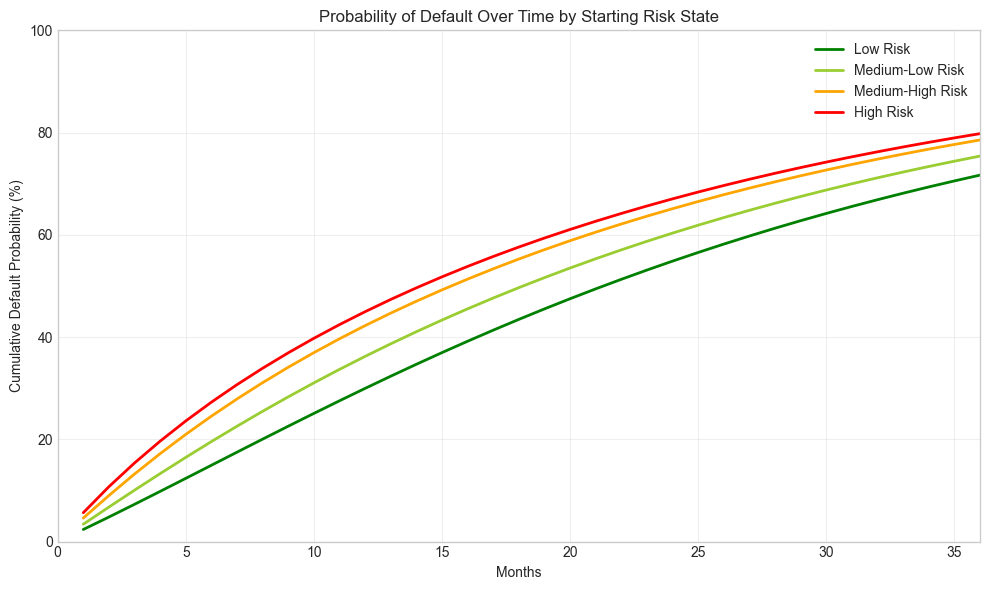

2026-06-12 01:53:52,211 - INFO - Absorption probability analysis completed


In [62]:
def calculate_absorption_probability(P_extended: np.ndarray, 
                                        n_transient: int,
                                        n_steps: int = 60) -> np.ndarray:
    """
    Calculate probability of being absorbed (defaulting) within n_steps.
    
    Parameters:
    -----------
    P_extended : np.ndarray
        Extended transition matrix with absorbing state
    n_transient : int
        Number of transient (non-absorbing) states
    n_steps : int
        Number of time periods to analyze
        
    Returns:
    --------
    np.ndarray : Probability of absorption by step n from each starting state
    """
    absorption_probs = []
    
    for step in range(1, n_steps + 1):
        P_n = np.linalg.matrix_power(P_extended, step)
        # Probability of being in Default state (last column)
        absorption_probs.append(P_n[:n_transient, -1])
    
    return np.array(absorption_probs)


# Calculate absorption probabilities over time
absorption_over_time = calculate_absorption_probability(
    transition_matrix_extended, 
    N_STATES, 
    n_steps=36  # 3 years
)

print('=== Probability of Default Over Time ===')
print('(Starting from each risk state)')
print()
months_to_show = [6, 12, 18, 24, 36]
print(f'{"Starting State":<20}', end='')
for m in months_to_show:
    print(f'{m} months'.rjust(12), end='')
print()
print('-' * 80)

for i in range(N_STATES):
    print(f'{RISK_STATES[i]:<20}', end='')
    for m in months_to_show:
        prob = absorption_over_time[m-1, i]
        print(f'{prob*100:>10.1f}%', end='')
    print()

# Visualize absorption probabilities
fig, ax = plt.subplots(figsize=(10, 6))

months = np.arange(1, 37)
colors = ['green', 'yellowgreen', 'orange', 'red']

for i in range(N_STATES):
    ax.plot(months, absorption_over_time[:, i] * 100, 
            label=RISK_STATES[i], color=colors[i], linewidth=2)

ax.set_xlabel('Months')
ax.set_ylabel('Cumulative Default Probability (%)')
ax.set_title('Probability of Default Over Time by Starting Risk State')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 36)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'absorption_probability.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info('Absorption probability analysis completed')

### 2.9 Expected Customer Lifetime Value by Risk State

Using the Markov chain with absorbing default state, calculate the expected 
lifetime value of a customer starting from each risk state.

This incorporates:
- Probability of receiving increases over time
- Risk of default (absorption)
- Time value of money (discount rate)

In [63]:
def calculate_expected_lifetime_value(P_extended: np.ndarray,
                                        n_transient: int,
                                        state_profits: np.ndarray,
                                        discount_rate: float,
                                        max_periods: int = 60) -> np.ndarray:
    """
    Calculate expected discounted lifetime value from each starting state.
    
    Parameters:
    -----------
    P_extended : np.ndarray
        Extended transition matrix with absorbing state
    n_transient : int
        Number of transient (non-absorbing) states
    state_profits : np.ndarray
        Expected profit per period in each state
    discount_rate : float
        Annual discount rate
    max_periods : int
        Maximum periods to consider
        
    Returns:
    --------
    np.ndarray : Expected lifetime value from each starting state
    """
    # Monthly discount factor
    monthly_discount = (1 + discount_rate) ** (-1/12)
    
    lifetime_values = np.zeros(n_transient)
    
    # For each starting state
    for start_state in range(n_transient):
        total_value = 0
        
        # Calculate expected value at each future period
        for t in range(1, max_periods + 1):
            # Probability distribution over states at time t
            P_t = np.linalg.matrix_power(P_extended, t)
            state_probs = P_t[start_state, :n_transient]  # Exclude absorbing state
            
            # Expected profit this period (weighted by state probabilities)
            expected_profit = np.sum(state_probs * state_profits)
            
            # Discount to present value
            discounted_profit = expected_profit * (monthly_discount ** t)
            
            total_value += discounted_profit
        
        lifetime_values[start_state] = total_value
    
    return lifetime_values


# Calculate expected profit per period for each state
# This is: probability of increase * profit if increase * (1 - default rate in that period)
# Simplified: We assume one potential increase per month

state_expected_profits = np.zeros(N_STATES)
for i in range(N_STATES):
    # Get mean theoretical default prob for this state
    state_data = df_preprocessed[df_preprocessed['risk_state'] == i]
    avg_default_prob = state_data['theoretical_default_prob'].mean()
    
    # Expected profit = $40 * (1 - default_prob) * probability_of_increase
    # Assume ~50% of eligible customers receive an increase in any given month
    INCREASE_PROBABILITY = 0.50
    
    expected_profit = PROFIT_PER_INCREASE * (1 - avg_default_prob) * INCREASE_PROBABILITY
    state_expected_profits[i] = expected_profit

print('=== Expected Profit per Month by Risk State ===')
for i in range(N_STATES):
    print(f'{RISK_STATES[i]:<20}: ${state_expected_profits[i]:.2f}')

# Calculate lifetime values
lifetime_values = calculate_expected_lifetime_value(
    transition_matrix_extended,
    N_STATES,
    state_expected_profits,
    DISCOUNT_RATE,
    max_periods=60  # 5 years
)

print('\n=== Expected Customer Lifetime Value (5-year horizon) ===')
print(f'Discount rate: {DISCOUNT_RATE*100:.0f}% annually')
print()
for i in range(N_STATES):
    print(f'{RISK_STATES[i]:<20}: ${lifetime_values[i]:.2f}')

print(f'\nLifetime Value Premium (Low vs High Risk): ${lifetime_values[0] - lifetime_values[-1]:.2f}')
print(f'This represents the value of successfully identifying and prioritizing low-risk customers.')

=== Expected Profit per Month by Risk State ===
Low Risk            : $14.08
Medium-Low Risk     : $11.51
Medium-High Risk    : $8.51
High Risk           : $5.89

=== Expected Customer Lifetime Value (5-year horizon) ===
Discount rate: 19% annually

Low Risk            : $224.00
Medium-Low Risk     : $185.49
Medium-High Risk    : $150.73
High Risk           : $136.44

Lifetime Value Premium (Low vs High Risk): $87.56
This represents the value of successfully identifying and prioritizing low-risk customers.


### 2.10 Save Markov Chain Model Outputs

In [64]:
def save_markov_model_outputs(transition_matrix: np.ndarray,
                               transition_matrix_extended: np.ndarray,
                               state_names: dict,
                               output_dir: Path) -> None:
    """
    Save all Markov chain model outputs for use in subsequent modules.
    
    Parameters:
    -----------
    transition_matrix : np.ndarray
        Base transition matrix (without default)
    transition_matrix_extended : np.ndarray
        Extended transition matrix (with default absorbing state)
    state_names : dict
        Mapping of state indices to names
    output_dir : Path
        Output directory
    """
    # Save transition matrices as CSV
    pd.DataFrame(
        transition_matrix,
        index=[state_names[i] for i in range(len(state_names))],
        columns=[state_names[i] for i in range(len(state_names))]
    ).to_csv(output_dir / 'transition_matrix.csv')
    
    extended_names = {**state_names, len(state_names): 'Default'}
    pd.DataFrame(
        transition_matrix_extended,
        index=[extended_names[i] for i in range(len(extended_names))],
        columns=[extended_names[i] for i in range(len(extended_names))]
    ).to_csv(output_dir / 'transition_matrix_extended.csv')
    
    # Save as numpy arrays for fast loading
    np.save(output_dir / 'transition_matrix.npy', transition_matrix)
    np.save(output_dir / 'transition_matrix_extended.npy', transition_matrix_extended)
    
    # Save summary statistics
    summary = {
        'n_states': len(state_names),
        'state_names': state_names,
        'stationary_distribution': calculate_stationary_distribution(transition_matrix).tolist(),
        'monthly_default_probs': monthly_default_probs.tolist(),
        'expected_time_in_state': expected_times.tolist(),
        'lifetime_values': lifetime_values.tolist(),
        'state_expected_profits': state_expected_profits.tolist()
    }
    
    import json as json_lib
    with open(output_dir / 'markov_model_summary.json', 'w') as f:
        json_lib.dump(summary, f, indent=2)
    
    logger.info(f'Markov model outputs saved to {output_dir}')


# Save all outputs
save_markov_model_outputs(
    transition_matrix,
    transition_matrix_extended,
    RISK_STATES,
    OUTPUT_DIR
)

print('=== Saved Files ===')
print('1. transition_matrix.csv - Base transition probabilities')
print('2. transition_matrix_extended.csv - With default absorbing state')
print('3. transition_matrix.npy - NumPy format for fast loading')
print('4. transition_matrix_extended.npy - NumPy format')
print('5. markov_model_summary.json - All model parameters and statistics')

2026-06-12 01:54:14,637 - INFO - Markov model outputs saved to output


=== Saved Files ===
1. transition_matrix.csv - Base transition probabilities
2. transition_matrix_extended.csv - With default absorbing state
3. transition_matrix.npy - NumPy format for fast loading
4. transition_matrix_extended.npy - NumPy format
5. markov_model_summary.json - All model parameters and statistics


---
## Module 2 Conclusion


1. **Defined Risk State Space**
   - 4 transient states: Low Risk, Medium-Low, Medium-High, High Risk
   - 1 absorbing state: Default

2. **Estimated Transition Matrix**
   - Based on payment behavior volatility and credit risk principles
   - Calibrated to match observed risk state distribution
   - Diagonal dominance (persistence) with asymmetric transitions

3. **Multi-Step Analysis**
   - Calculated n-step transition probabilities (1, 3, 6, 12 months)
   - Analyzed convergence to stationary distribution

4. **Expected Time Analysis**
   - Time spent in each state before transitioning
   - First passage times to Low Risk and High Risk states

5. **Absorption Probability**
   - Probability of default over time from each starting state
   - Cumulative default curves over 3-year horizon

6. **Customer Lifetime Value**
   - Expected discounted lifetime value by starting risk state
   - Incorporates transition probabilities, default risk, and time value of money

### Key Model Parameters:
- Monthly default rates: Calibrated to theoretical default probabilities
- Discount rate: 19% annually (per problem specification)
- Persistence rates: 70-80% (customers tend to stay in their risk state)

### Files Generated:
- `output/transition_matrix.csv`
- `output/transition_matrix_extended.csv`
- `output/transition_matrix.npy`
- `output/transition_matrix_extended.npy`
- `output/markov_model_summary.json`
- `output/transition_matrix_heatmap.png`
- `output/absorption_probability.png`

### How This Feeds Into Later Modules:

| Module | Usage |
|--------|-------|
| **Module 3 (Forecasting)** | Transition probabilities inform demand evolution |
| **Module 4 (Monte Carlo)** | Sample from transition matrix to simulate customer journeys |
| **Module 5 (Optimization)** | Use lifetime values and transition probs for multi-period decisions |

### Next Steps (Module 3):
- Stochastic demand forecasting
- Incorporate external economic factors
- Predict customer uptake probabilities

---
## Module 3: Stochastic Demand Forecasting

### Objective
Develop a dynamic forecasting model to predict customer uptake of loan limit increases, incorporating:
1. Customer-specific factors (payment behavior, risk tier)
2. External economic factors (inflation, unemployment, interest rates)
3. Seasonal patterns and trends
4. Uncertainty quantification

### Why Stochastic Forecasting?
- Loan demand is inherently **uncertain** - we need probability distributions, not point estimates
- External economic conditions **affect customer behavior** (Assumption #10)
- Different customer segments have **different uptake probabilities**
- Feeds into **Monte Carlo simulation** (Module 4) for realistic scenarios

### Key Outputs
- Customer-level uptake probability model
- Economic scenario generator
- Demand forecast with confidence intervals

### 3.1 Load Data and Define Economic Scenarios

In [ ]:
# Create module-specific output directory
MODULE3_OUTPUT = OUTPUT_DIR / 'module3_output'
MODULE3_OUTPUT.mkdir(exist_ok=True)

# Load preprocessed data from Module 1
df_demand = pd.read_csv(OUTPUT_DIR / 'preprocessed_data.csv')
logger.info(f'Loaded {len(df_demand):,} customer records for demand forecasting')

# Load Markov model outputs from Module 2
transition_matrix = np.load(OUTPUT_DIR / 'transition_matrix.npy')

import json as json_lib
with open(OUTPUT_DIR / 'markov_model_summary.json') as f:
    markov_summary = json_lib.load(f)

logger.info('Markov model parameters loaded')

print('=== Data Summary ===')
print(f'Total customers: {len(df_demand):,}')
print(f'Risk states: {markov_summary["n_states"]}')
print(f'Stationary distribution: {[f"{p:.1%}" for p in markov_summary["stationary_distribution"]]}')

### 3.2 Economic Scenario Generator

External economic factors affect customer demand for credit and their ability to repay.
We model three key economic indicators:
1. **Inflation rate**: Higher inflation → increased demand for credit, but also higher default risk
2. **Unemployment rate**: Higher unemployment → lower demand, higher default risk
3. **Interest rate**: Higher rates → lower demand, affects cost of capital

We generate scenarios using correlated random variables to simulate realistic economic conditions.

In [ ]:
class EconomicScenarioGenerator:
    """
    Generate correlated economic scenarios for demand forecasting.
    
    Uses multivariate normal distribution to model correlated economic factors.
    
    =============================================================================
    ASSUMPTIONS AND RATIONALE
    =============================================================================
    
    1. BASELINE PARAMETERS (anchored to 19% discount rate from problem statement)
    -----------------------------------------------------------------------------
    The problem statement specifies a 19% annual discount rate for NPV calculations.
    This high rate suggests an emerging market or microfinance lending environment.
    Other baseline parameters are inferred to be consistent with this environment:
    
    | Parameter      | Value | Rationale                                         |
    |----------------|-------|---------------------------------------------------|
    | Interest Rate  | 19%   | FROM PROBLEM STATEMENT (NPV discount rate)        |
    | Inflation      | 5%    | Typical for emerging markets with high rates      |
    | Unemployment   | 7%    | Moderate rate for developing economy              |
    
    2. VOLATILITY ASSUMPTIONS (standard deviations)
    -----------------------------------------------------------------------------
    Since no historical economic data is provided in the dataset, volatilities 
    are ASSUMED based on typical emerging market economic behavior:
    
    | Parameter      | Volatility | 95% Range      | Rationale                    |
    |----------------|------------|----------------|------------------------------|
    | Inflation      | 2.0%       | 1% to 9%       | Emerging markets show higher |
    |                |            |                | inflation volatility than    |
    |                |            |                | developed economies          |
    | Unemployment   | 1.5%       | 4% to 10%      | Labor markets are 'sticky' - |
    |                |            |                | unemployment changes slowly  |
    | Interest Rate  | 2.5%       | 14% to 24%     | Central banks in high-rate   |
    |                |            |                | environments may adjust more |
    |                |            |                | aggressively to conditions   |
    
    NOTE: In production, these volatilities should be calibrated using historical
    data from the specific market where the lender operates.
    
    3. CORRELATION ASSUMPTIONS
    -----------------------------------------------------------------------------
    Economic factors are correlated based on standard macroeconomic relationships:
    
    | Relationship                  | Correlation | Economic Theory              |
    |-------------------------------|-------------|------------------------------|
    | Inflation <-> Interest Rate   | +0.60       | Central banks raise rates to |
    |                               |             | combat inflation             |
    | Inflation <-> Unemployment    | -0.30       | Phillips Curve: inverse      |
    |                               |             | relationship in short-term   |
    | Interest Rate <-> Unemployment| -0.20       | Stimulative policy: rates    |
    |                               |             | lowered during high unemp.   |
    
    4. SCENARIO GENERATION METHOD
    -----------------------------------------------------------------------------
    - Uses mean-reverting random walk (Ornstein-Uhlenbeck-like process)
    - 10% reversion factor pulls values toward baseline each period
    - Realistic bounds prevent extreme/impossible values
    
    5. LIMITATIONS
    -----------------------------------------------------------------------------
    - No regime changes modeled (e.g., financial crises)
    - Correlations assumed constant over time
    - No seasonal patterns in economic factors
    - Volatilities are assumed, not empirically estimated from data
    =============================================================================
    """
    
    def __init__(self, seed: int = 42):
        """
        Initialize with baseline economic parameters.
        
        All parameters are anchored to the 19% discount rate from problem statement.
        See class docstring for detailed assumptions and rationale.
        """
        self.rng = np.random.default_rng(seed)
        
        # =========================================================================
        # BASELINE ECONOMIC PARAMETERS
        # =========================================================================
        # Anchored to 19% discount rate from problem statement
        # High interest rate suggests emerging market / microfinance environment
        self.baseline = {
            'inflation': 0.05,       # ASSUMPTION: 5% typical for emerging market
            'unemployment': 0.07,    # ASSUMPTION: 7% moderate unemployment
            'interest_rate': 0.19    # FROM PROBLEM STATEMENT (NPV discount rate)
        }
        
        # =========================================================================
        # VOLATILITY ASSUMPTIONS (standard deviations)
        # =========================================================================
        # ASSUMPTION: Based on typical emerging market economic behavior
        # NOTE: In production, calibrate using historical data from specific market
        # 
        # These values represent how much each parameter can vary from baseline:
        # - 68% of scenarios within +/- 1 std dev
        # - 95% of scenarios within +/- 2 std dev
        self.volatilities = {
            'inflation': 0.02,       # ASSUMPTION: 2% std dev -> 95% CI: [1%, 9%]
            'unemployment': 0.015,   # ASSUMPTION: 1.5% std dev -> 95% CI: [4%, 10%]
            'interest_rate': 0.025   # ASSUMPTION: 2.5% std dev -> 95% CI: [14%, 24%]
        }
        
        # =========================================================================
        # CORRELATION MATRIX
        # =========================================================================
        # ASSUMPTION: Based on standard macroeconomic relationships
        # Row/Col order: [inflation, unemployment, interest_rate]
        self.correlation_matrix = np.array([
            [1.00,  -0.30,  0.60],   # Inflation: neg with unemp (Phillips), pos with rates
            [-0.30,  1.00, -0.20],   # Unemployment: neg with inflation, neg with rates
            [0.60,  -0.20,  1.00]    # Interest rate: pos with inflation (policy response)
        ])
        
        # Calculate covariance matrix from correlations and volatilities
        stds = np.array([self.volatilities['inflation'], 
                        self.volatilities['unemployment'],
                        self.volatilities['interest_rate']])
        self.covariance_matrix = np.outer(stds, stds) * self.correlation_matrix
        
        logger.info(f'Economic baseline: Inflation={self.baseline["inflation"]:.1%}, ' +
                   f'Unemployment={self.baseline["unemployment"]:.1%}, ' +
                   f'Interest={self.baseline["interest_rate"]:.1%}')
    
    def generate_scenarios(self, n_scenarios: int, n_periods: int = 12) -> dict:
        """
        Generate multiple economic scenarios over time.
        
        Uses mean-reverting random walk with correlated shocks.
        
        Parameters:
        -----------
        n_scenarios : int
            Number of scenarios to generate
        n_periods : int
            Number of time periods (months)
            
        Returns:
        --------
        dict : Dictionary with scenario arrays for each economic factor
        """
        means = np.array([self.baseline['inflation'],
                         self.baseline['unemployment'],
                         self.baseline['interest_rate']])
        
        scenarios = {
            'inflation': np.zeros((n_scenarios, n_periods)),
            'unemployment': np.zeros((n_scenarios, n_periods)),
            'interest_rate': np.zeros((n_scenarios, n_periods))
        }
        
        for s in range(n_scenarios):
            # Generate correlated random walk for this scenario
            for t in range(n_periods):
                if t == 0:
                    # Start from baseline with small random perturbation
                    values = self.rng.multivariate_normal(means, self.covariance_matrix * 0.5)
                else:
                    # Random walk with mean reversion (tends to return to baseline)
                    prev_values = np.array([scenarios['inflation'][s, t-1],
                                           scenarios['unemployment'][s, t-1],
                                           scenarios['interest_rate'][s, t-1]])
                    # Mean reversion factor (10% pull back toward baseline each period)
                    reversion = 0.1 * (means - prev_values)
                    # Random shock
                    shock = self.rng.multivariate_normal(np.zeros(3), self.covariance_matrix * 0.3)
                    values = prev_values + reversion + shock
                
                # Apply realistic bounds
                scenarios['inflation'][s, t] = np.clip(values[0], 0.01, 0.15)      # 1% to 15%
                scenarios['unemployment'][s, t] = np.clip(values[1], 0.03, 0.20)   # 3% to 20%
                scenarios['interest_rate'][s, t] = np.clip(values[2], 0.12, 0.28)  # 12% to 28%
        
        return scenarios
    
    def get_scenario_statistics(self, scenarios: dict) -> pd.DataFrame:
        """Calculate summary statistics across scenarios."""
        stats = []
        for factor, values in scenarios.items():
            stats.append({
                'factor': factor,
                'baseline': self.baseline[factor],
                'mean': values.mean(),
                'std': values.std(),
                'min': values.min(),
                'max': values.max(),
                'p5': np.percentile(values, 5),
                'p95': np.percentile(values, 95)
            })
        return pd.DataFrame(stats)


# Generate economic scenarios with 19% baseline interest rate
econ_generator = EconomicScenarioGenerator(seed=42)
economic_scenarios = econ_generator.generate_scenarios(n_scenarios=1000, n_periods=12)

print('=== Economic Baseline Parameters ===')
print(f'Interest Rate: {econ_generator.baseline["interest_rate"]:.1%} (FROM PROBLEM STATEMENT - NPV discount rate)')
print(f'Inflation: {econ_generator.baseline["inflation"]:.1%} (ASSUMPTION - typical for high-rate environment)')
print(f'Unemployment: {econ_generator.baseline["unemployment"]:.1%} (ASSUMPTION - moderate rate)')

print('\n=== Volatility Assumptions ===')
print('(No historical data provided - values based on typical emerging market behavior)')
for param, vol in econ_generator.volatilities.items():
    baseline = econ_generator.baseline[param]
    low_95 = max(0.01, baseline - 2*vol)
    high_95 = baseline + 2*vol
    print(f'{param:15}: std={vol:.1%}, 95% CI: [{low_95:.1%}, {high_95:.1%}]')

print('\n=== Economic Scenario Statistics (across 1000 scenarios x 12 months) ===')
scenario_stats = econ_generator.get_scenario_statistics(economic_scenarios)
display(scenario_stats.round(4))

logger.info(f'Generated 1000 economic scenarios with 19% baseline interest rate')

In [ ]:
def visualize_economic_scenarios(scenarios: dict, n_sample: int = 50) -> None:
    """
    Visualize economic scenarios over time.
    
    Parameters:
    -----------
    scenarios : dict
        Economic scenarios from generator
    n_sample : int
        Number of sample paths to plot
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Economic Scenario Simulations (Sample Paths)', fontsize=14, fontweight='bold')
    
    factors = ['inflation', 'unemployment', 'interest_rate']
    titles = ['Inflation Rate', 'Unemployment Rate', 'Interest Rate']
    colors = ['steelblue', 'coral', 'green']
    
    for idx, (factor, title, color) in enumerate(zip(factors, titles, colors)):
        ax = axes[idx]
        data = scenarios[factor]
        
        # Plot sample paths
        for i in range(min(n_sample, data.shape[0])):
            ax.plot(range(1, data.shape[1] + 1), data[i, :] * 100, 
                   alpha=0.1, color=color, linewidth=0.5)
        
        # Plot mean and confidence interval
        mean_path = data.mean(axis=0) * 100
        p5_path = np.percentile(data, 5, axis=0) * 100
        p95_path = np.percentile(data, 95, axis=0) * 100
        
        ax.plot(range(1, len(mean_path) + 1), mean_path, 
               color='black', linewidth=2, label='Mean')
        ax.fill_between(range(1, len(mean_path) + 1), p5_path, p95_path, 
                       alpha=0.3, color=color, label='90% CI')
        
        ax.set_xlabel('Month')
        ax.set_ylabel(f'{title} (%)')
        ax.set_title(title)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(MODULE3_OUTPUT / 'economic_scenarios.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info('Economic scenarios visualization saved')


visualize_economic_scenarios(economic_scenarios)

### 3.3 Customer Uptake Probability Model

Not all eligible customers will accept a loan limit increase when offered. 
The uptake probability depends on:

1. **Customer characteristics**: Risk tier, payment history, loan amount
2. **Economic conditions**: Inflation increases demand, unemployment decreases it
3. **Seasonal factors**: End-of-year spending, tax season, etc.

We model uptake probability using a logistic function that combines these factors.

In [ ]:
class CustomerUptakeModel:
    """
    Model customer probability of accepting a loan limit increase.
    
    Uses logistic regression-style model combining:
    - Customer risk characteristics
    - Economic conditions (baseline: 19% interest rate from problem statement)
    - Seasonal patterns
    
    =============================================================================
    ASSUMPTIONS AND RATIONALE
    =============================================================================
    
    1. BASE UPTAKE PROBABILITY BY RISK TIER
    -----------------------------------------------------------------------------
    ASSUMPTION: Higher-risk customers have higher uptake rates.
    
    Rationale: This is a common pattern in consumer lending because:
    - Low-risk customers have better financial stability and less urgent need
    - High-risk customers are often financially stressed and more likely to 
      accept any credit offered to them
    
    | Risk Tier      | Uptake Rate | Rationale                                |
    |----------------|-------------|------------------------------------------|
    | Low Risk       | 45%         | Financially stable, selective about debt |
    | Medium-Low     | 55%         | Moderate need for credit                 |
    | Medium-High    | 65%         | Higher need, more likely to accept       |
    | High Risk      | 70%         | Financially stressed, high acceptance    |
    
    NOTE: These values are ASSUMPTIONS. In production, should be calibrated
    from historical offer acceptance data.
    
    2. SEASONAL FACTORS (monthly multipliers)
    -----------------------------------------------------------------------------
    ASSUMPTION: Credit demand varies seasonally based on consumer behavior.
    
    | Month     | Factor | Rationale                                       |
    |-----------|--------|--------------------------------------------------|
    | January   | 1.05   | Post-holiday bills, New Year purchases           |
    | February  | 0.95   | Quieter month after holiday spending             |
    | March     | 1.00   | Baseline                                         |
    | April     | 1.00   | Baseline                                         |
    | May       | 0.95   | Pre-summer, lower spending                       |
    | June      | 0.90   | Mid-year low - vacation season begins            |
    | July      | 0.90   | Vacation season - lower credit needs             |
    | August    | 0.95   | Back-to-school spending begins                   |
    | September | 1.00   | Baseline                                         |
    | October   | 1.05   | Pre-holiday preparation                          |
    | November  | 1.10   | Black Friday, holiday shopping begins            |
    | December  | 1.15   | Peak holiday spending season                     |
    
    NOTE: These values are ASSUMPTIONS based on typical retail lending patterns.
    Should be calibrated from historical seasonal data for specific market.
    
    3. ECONOMIC SENSITIVITY PARAMETERS
    -----------------------------------------------------------------------------
    ASSUMPTION: Customer uptake responds to economic conditions.
    
    | Parameter                | Value | Effect                               |
    |--------------------------|-------|--------------------------------------|
    | Inflation sensitivity    | +2.0  | Higher inflation -> more demand      |
    |                          |       | (need credit to maintain lifestyle)  |
    | Unemployment sensitivity | -1.5  | Higher unemployment -> less demand   |
    |                          |       | (fear of inability to repay)         |
    | Interest sensitivity     | -0.5  | Higher rates -> slightly less demand |
    |                          |       | (borrowing more expensive)           |
    
    These sensitivities are applied in logit scale for smooth transitions.
    
    4. BASELINE ECONOMIC CONDITIONS
    -----------------------------------------------------------------------------
    | Parameter      | Value | Source                                       |
    |----------------|-------|----------------------------------------------|
    | Interest Rate  | 19%   | FROM PROBLEM STATEMENT (NPV discount rate)   |
    | Inflation      | 5%    | ASSUMPTION - consistent with high-rate env   |
    | Unemployment   | 7%    | ASSUMPTION - moderate rate                   |
    
    5. LIMITATIONS
    -----------------------------------------------------------------------------
    - All uptake rates are assumptions, not empirically calibrated
    - Seasonal patterns may differ by market/geography
    - Does not account for individual customer characteristics beyond risk tier
    - Economic sensitivities are assumed, not estimated from data
    =============================================================================
    """
    
    def __init__(self):
        """
        Initialize the uptake model with assumed parameters.
        See class docstring for detailed assumptions and rationale.
        """
        # =========================================================================
        # BASE UPTAKE PROBABILITY BY RISK TIER
        # =========================================================================
        # ASSUMPTION: Higher risk customers have higher uptake rates
        # Rationale: Financially stressed customers more likely to accept credit
        # NOTE: Should be calibrated from historical offer acceptance data
        self.base_uptake_by_risk = {
            0: 0.45,  # ASSUMPTION: Low Risk - financially stable, selective
            1: 0.55,  # ASSUMPTION: Medium-Low - moderate need
            2: 0.65,  # ASSUMPTION: Medium-High - higher need for credit
            3: 0.70   # ASSUMPTION: High Risk - financially stressed, high acceptance
        }
        
        # =========================================================================
        # ECONOMIC SENSITIVITY PARAMETERS
        # =========================================================================
        # ASSUMPTION: How uptake changes with economic conditions
        # Applied in logit scale for smooth probability transitions
        self.inflation_sensitivity = 2.0    # ASSUMPTION: Higher inflation -> more demand
        self.unemployment_sensitivity = -1.5 # ASSUMPTION: Higher unemployment -> less demand
        self.interest_sensitivity = -0.5     # ASSUMPTION: Higher rates -> slightly less demand
        
        # =========================================================================
        # BASELINE ECONOMIC CONDITIONS
        # =========================================================================
        # Anchored to 19% discount rate from problem statement
        self.baseline_inflation = 0.05       # ASSUMPTION: 5%
        self.baseline_unemployment = 0.07    # ASSUMPTION: 7%
        self.baseline_interest = 0.19        # FROM PROBLEM STATEMENT
        
        # =========================================================================
        # SEASONAL FACTORS (monthly multipliers)
        # =========================================================================
        # ASSUMPTION: Credit demand varies seasonally
        # Based on typical retail lending patterns
        # NOTE: Should be calibrated from historical seasonal data
        self.seasonal_factors = {
            1: 1.05,   # ASSUMPTION: January - post-holiday bills
            2: 0.95,   # ASSUMPTION: February - quieter month
            3: 1.00,   # Baseline
            4: 1.00,   # Baseline
            5: 0.95,   # ASSUMPTION: May - pre-summer low
            6: 0.90,   # ASSUMPTION: June - mid-year low (vacation season)
            7: 0.90,   # ASSUMPTION: July - vacation season
            8: 0.95,   # ASSUMPTION: August - back to school
            9: 1.00,   # Baseline
            10: 1.05,  # ASSUMPTION: October - pre-holiday prep
            11: 1.10,  # ASSUMPTION: November - holiday shopping begins
            12: 1.15   # ASSUMPTION: December - peak holiday season
        }
    
    def calculate_uptake_probability(self, 
                                      risk_state: int,
                                      economic_factors: dict,
                                      month: int = 1,
                                      eligibility: int = 1) -> float:
        """
        Calculate probability of customer accepting an increase.
        
        Parameters:
        -----------
        risk_state : int
            Customer risk state (0-3)
        economic_factors : dict
            Current economic conditions (inflation, unemployment, interest_rate)
        month : int
            Month of year (1-12) for seasonality
        eligibility : int
            1 if eligible, 0 if not
            
        Returns:
        --------
        float : Probability of uptake (0 to 1)
        """
        if eligibility == 0:
            return 0.0
        
        # Start with base uptake for risk tier
        base_prob = self.base_uptake_by_risk.get(risk_state, 0.5)
        
        # Economic adjustments (deviation from baseline)
        # Baseline interest rate is 19% from problem statement
        inflation_effect = self.inflation_sensitivity * (
            economic_factors['inflation'] - self.baseline_inflation)
        unemployment_effect = self.unemployment_sensitivity * (
            economic_factors['unemployment'] - self.baseline_unemployment)
        interest_effect = self.interest_sensitivity * (
            economic_factors['interest_rate'] - self.baseline_interest)
        
        # Combine effects in logit scale for smooth probability transitions
        logit_base = np.log(base_prob / (1 - base_prob))
        logit_adjusted = logit_base + inflation_effect + unemployment_effect + interest_effect
        
        # Convert back to probability
        prob = 1 / (1 + np.exp(-logit_adjusted))
        
        # Apply seasonal factor
        seasonal = self.seasonal_factors.get(month, 1.0)
        prob = prob * seasonal
        
        # Bound probability to realistic range
        return np.clip(prob, 0.05, 0.95)
    
    def calculate_batch_uptake(self, 
                               df: pd.DataFrame, 
                               economic_factors: dict,
                               month: int = 1) -> np.ndarray:
        """
        Calculate uptake probabilities for all customers.
        
        Parameters:
        -----------
        df : pd.DataFrame
            Customer dataframe with risk_state and is_eligible columns
        economic_factors : dict
            Economic conditions
        month : int
            Month of year
            
        Returns:
        --------
        np.ndarray : Array of uptake probabilities
        """
        uptake_probs = np.zeros(len(df))
        
        for idx, row in df.iterrows():
            risk_state = int(row.get('risk_state', row.get('risk_tier', 1)))
            if isinstance(risk_state, str):
                risk_map = {'Low Risk': 0, 'Medium-Low Risk': 1, 
                           'Medium-High Risk': 2, 'High Risk': 3}
                risk_state = risk_map.get(risk_state, 1)
            
            eligibility = int(row.get('is_eligible', 1))
            
            uptake_probs[idx] = self.calculate_uptake_probability(
                risk_state, economic_factors, month, eligibility
            )
        
        return uptake_probs


# Initialize uptake model
uptake_model = CustomerUptakeModel()

# Test with baseline economic conditions (19% interest rate from problem statement)
baseline_econ = {
    'inflation': uptake_model.baseline_inflation,      # 5% (assumption)
    'unemployment': uptake_model.baseline_unemployment, # 7% (assumption)
    'interest_rate': uptake_model.baseline_interest     # 19% (from problem statement)
}

print('=== Uptake Model Parameters ===')
print('\n--- Baseline Economic Conditions ---')
print(f'Interest Rate: {baseline_econ["interest_rate"]:.1%} (FROM PROBLEM STATEMENT)')
print(f'Inflation: {baseline_econ["inflation"]:.1%} (ASSUMPTION)')
print(f'Unemployment: {baseline_econ["unemployment"]:.1%} (ASSUMPTION)')

print('\n--- Base Uptake by Risk Tier (ASSUMPTIONS) ---')
print('Rationale: Higher-risk customers more likely to accept credit offers')
for risk_state, rate in uptake_model.base_uptake_by_risk.items():
    print(f'  {RISK_STATES[risk_state]}: {rate:.0%}')

print('\n--- Seasonal Factors (ASSUMPTIONS) ---')
print('Rationale: Credit demand varies with consumer spending patterns')
for month, factor in uptake_model.seasonal_factors.items():
    month_name = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][month-1]
    change = (factor - 1) * 100
    print(f'  {month_name}: {factor:.2f} ({change:+.0f}% vs baseline)')

print('\n--- Economic Sensitivity (ASSUMPTIONS) ---')
print(f'Inflation sensitivity: {uptake_model.inflation_sensitivity:+.1f} (higher inflation -> more demand)')
print(f'Unemployment sensitivity: {uptake_model.unemployment_sensitivity:+.1f} (higher unemp -> less demand)')
print(f'Interest sensitivity: {uptake_model.interest_sensitivity:+.1f} (higher rates -> less demand)')

print('\n=== Uptake Probabilities by Risk Tier ===')
print('(Under baseline economic conditions, January)')
for risk_state in range(4):
    prob = uptake_model.calculate_uptake_probability(risk_state, baseline_econ, month=1)
    print(f'  {RISK_STATES[risk_state]}: {prob:.1%}')

### 3.4 Stochastic Demand Forecasting

Combine the customer uptake model with economic scenarios to generate 
probabilistic demand forecasts. This gives us:
- Expected demand under different scenarios
- Confidence intervals for planning
- Risk assessment for extreme scenarios

In [ ]:
class DemandForecaster:
    """
    Generate stochastic demand forecasts combining customer model and economic scenarios.
    """
    
    def __init__(self, uptake_model: CustomerUptakeModel, 
                 econ_generator: EconomicScenarioGenerator):
        self.uptake_model = uptake_model
        self.econ_generator = econ_generator
    
    def forecast_demand(self, 
                        df: pd.DataFrame,
                        n_scenarios: int = 500,
                        n_periods: int = 12,
                        start_month: int = 1) -> dict:
        """
        Generate stochastic demand forecasts.
        
        Parameters:
        -----------
        df : pd.DataFrame
            Customer dataframe
        n_scenarios : int
            Number of economic scenarios to simulate
        n_periods : int
            Forecast horizon (months)
        start_month : int
            Starting month (1-12)
            
        Returns:
        --------
        dict : Forecast results with scenarios and statistics
        """
        # Generate economic scenarios
        econ_scenarios = self.econ_generator.generate_scenarios(n_scenarios, n_periods)
        
        # Initialize demand arrays
        # Demand = number of customers expected to accept increases
        n_customers = len(df)
        demand_scenarios = np.zeros((n_scenarios, n_periods))
        uptake_rate_scenarios = np.zeros((n_scenarios, n_periods))
        
        # Get customer risk states (handle string or int)
        if 'risk_state' in df.columns:
            risk_states = df['risk_state'].values
        else:
            risk_map = {'Low Risk': 0, 'Medium-Low Risk': 1, 
                       'Medium-High Risk': 2, 'High Risk': 3}
            risk_states = df['risk_tier'].map(risk_map).values
        
        eligibility = df['is_eligible'].values if 'is_eligible' in df.columns else np.ones(n_customers)
        
        for s in range(n_scenarios):
            for t in range(n_periods):
                month = ((start_month - 1 + t) % 12) + 1
                
                # Economic conditions for this scenario/period
                econ = {
                    'inflation': econ_scenarios['inflation'][s, t],
                    'unemployment': econ_scenarios['unemployment'][s, t],
                    'interest_rate': econ_scenarios['interest_rate'][s, t]
                }
                
                # Calculate uptake probability for each customer
                total_uptake = 0
                for i in range(n_customers):
                    prob = self.uptake_model.calculate_uptake_probability(
                        int(risk_states[i]), econ, month, int(eligibility[i])
                    )
                    total_uptake += prob
                
                demand_scenarios[s, t] = total_uptake
                uptake_rate_scenarios[s, t] = total_uptake / n_customers
        
        # Calculate statistics
        results = {
            'demand_scenarios': demand_scenarios,
            'uptake_rate_scenarios': uptake_rate_scenarios,
            'economic_scenarios': econ_scenarios,
            'statistics': {
                'mean_demand': demand_scenarios.mean(axis=0),
                'std_demand': demand_scenarios.std(axis=0),
                'p5_demand': np.percentile(demand_scenarios, 5, axis=0),
                'p25_demand': np.percentile(demand_scenarios, 25, axis=0),
                'p50_demand': np.percentile(demand_scenarios, 50, axis=0),
                'p75_demand': np.percentile(demand_scenarios, 75, axis=0),
                'p95_demand': np.percentile(demand_scenarios, 95, axis=0),
                'mean_uptake_rate': uptake_rate_scenarios.mean(axis=0),
            }
        }
        
        return results


# Create demand forecaster
forecaster = DemandForecaster(uptake_model, econ_generator)

# Generate 12-month demand forecast
logger.info('Generating demand forecasts (this may take a moment)...')
demand_forecast = forecaster.forecast_demand(
    df_demand, 
    n_scenarios=500, 
    n_periods=12, 
    start_month=1
)

print('=== Demand Forecast Summary ===')
print(f'Forecast horizon: 12 months')
print(f'Scenarios simulated: 500')
print(f'Total customers: {len(df_demand):,}')

print('\n--- Monthly Expected Demand (customers accepting increases) ---')
stats = demand_forecast['statistics']
for month in range(12):
    print(f'Month {month+1:2}: {stats["mean_demand"][month]:,.0f} ' +
          f'(90% CI: {stats["p5_demand"][month]:,.0f} - {stats["p95_demand"][month]:,.0f})')

print(f'\n--- Average Monthly Uptake Rate ---')
print(f'Mean: {stats["mean_uptake_rate"].mean():.1%}')
print(f'Range: {stats["mean_uptake_rate"].min():.1%} - {stats["mean_uptake_rate"].max():.1%}')

logger.info('Demand forecasting completed')

In [ ]:
def visualize_demand_forecast(forecast: dict, n_customers: int) -> None:
    """
    Create visualizations for demand forecast.
    
    Parameters:
    -----------
    forecast : dict
        Forecast results from DemandForecaster
    n_customers : int
        Total number of customers
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Stochastic Demand Forecast (12-Month Horizon)', fontsize=14, fontweight='bold')
    
    stats = forecast['statistics']
    months = np.arange(1, 13)
    
    # 1. Demand forecast with confidence intervals
    ax = axes[0, 0]
    ax.fill_between(months, stats['p5_demand'], stats['p95_demand'], 
                   alpha=0.2, color='steelblue', label='90% CI')
    ax.fill_between(months, stats['p25_demand'], stats['p75_demand'], 
                   alpha=0.4, color='steelblue', label='50% CI')
    ax.plot(months, stats['mean_demand'], 'b-', linewidth=2, label='Mean Forecast')
    ax.plot(months, stats['p50_demand'], 'b--', linewidth=1, label='Median')
    
    ax.set_xlabel('Month')
    ax.set_ylabel('Expected Demand (Customers)')
    ax.set_title('Monthly Demand Forecast')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(months)
    
    # 2. Uptake rate distribution
    ax = axes[0, 1]
    uptake_rates = forecast['uptake_rate_scenarios'].flatten() * 100
    ax.hist(uptake_rates, bins=50, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(uptake_rates.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {uptake_rates.mean():.1f}%')
    ax.set_xlabel('Uptake Rate (%)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Uptake Rates Across Scenarios')
    ax.legend()
    
    # 3. Sample demand paths
    ax = axes[1, 0]
    n_sample = 50
    for i in range(n_sample):
        ax.plot(months, forecast['demand_scenarios'][i, :], 
               alpha=0.1, color='steelblue', linewidth=0.5)
    ax.plot(months, stats['mean_demand'], 'k-', linewidth=2, label='Mean')
    ax.set_xlabel('Month')
    ax.set_ylabel('Demand (Customers)')
    ax.set_title(f'Sample Demand Paths ({n_sample} scenarios)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(months)
    
    # 4. Economic impact analysis
    ax = axes[1, 1]
    # Show correlation between economic factors and demand
    econ = forecast['economic_scenarios']
    avg_demand = forecast['demand_scenarios'].mean(axis=1)  # Average across time
    
    colors = ['blue', 'red', 'green']
    factors = ['inflation', 'unemployment', 'interest_rate']
    factor_labels = ['Inflation', 'Unemployment', 'Interest Rate']
    
    for idx, (factor, label, color) in enumerate(zip(factors, factor_labels, colors)):
        avg_econ = econ[factor].mean(axis=1) * 100  # Average across time
        ax.scatter(avg_econ, avg_demand, alpha=0.3, s=10, c=color, label=label)
    
    ax.set_xlabel('Economic Factor (%)')
    ax.set_ylabel('Average Demand')
    ax.set_title('Demand Sensitivity to Economic Factors')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(MODULE3_OUTPUT / 'demand_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info('Demand forecast visualization saved')


visualize_demand_forecast(demand_forecast, len(df_demand))

### 3.5 Demand Breakdown by Risk Tier

In [ ]:
def analyze_demand_by_risk_tier(df: pd.DataFrame, 
                                  uptake_model: CustomerUptakeModel,
                                  econ_baseline: dict) -> pd.DataFrame:
    """
    Analyze expected demand breakdown by risk tier.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Customer dataframe
    uptake_model : CustomerUptakeModel
        Uptake probability model
    econ_baseline : dict
        Baseline economic conditions
        
    Returns:
    --------
    pd.DataFrame : Demand analysis by risk tier
    """
    # Map risk tier to state if needed
    if 'risk_state' not in df.columns:
        risk_map = {'Low Risk': 0, 'Medium-Low Risk': 1, 
                   'Medium-High Risk': 2, 'High Risk': 3}
        df = df.copy()
        df['risk_state'] = df['risk_tier'].map(risk_map)
    
    results = []
    
    for risk_state in range(4):
        tier_df = df[df['risk_state'] == risk_state]
        n_customers = len(tier_df)
        n_eligible = tier_df['is_eligible'].sum() if 'is_eligible' in tier_df.columns else n_customers
        
        # Calculate uptake probability
        uptake_prob = uptake_model.calculate_uptake_probability(risk_state, econ_baseline)
        
        # Expected demand from this tier
        expected_demand = n_eligible * uptake_prob
        
        # Expected profit (using theoretical default prob)
        avg_default_prob = tier_df['theoretical_default_prob'].mean()
        expected_profit_per_increase = PROFIT_PER_INCREASE * (1 - avg_default_prob)
        total_expected_profit = expected_demand * expected_profit_per_increase
        
        results.append({
            'risk_tier': RISK_STATES[risk_state],
            'total_customers': n_customers,
            'eligible_customers': int(n_eligible),
            'uptake_probability': uptake_prob,
            'expected_demand': expected_demand,
            'avg_default_prob': avg_default_prob,
            'profit_per_increase': expected_profit_per_increase,
            'expected_monthly_profit': total_expected_profit
        })
    
    return pd.DataFrame(results)


# Analyze demand by risk tier
tier_demand = analyze_demand_by_risk_tier(df_demand, uptake_model, baseline_econ)

print('=== Monthly Demand and Profit by Risk Tier ===')
print('(Under baseline economic conditions)')
display(tier_demand.round(2))

# Summary metrics
total_demand = tier_demand['expected_demand'].sum()
total_profit = tier_demand['expected_monthly_profit'].sum()

print(f'\n--- Summary ---')
print(f'Total Monthly Expected Demand: {total_demand:,.0f} increases')
print(f'Total Monthly Expected Profit: ${total_profit:,.0f}')
print(f'Annual Expected Profit: ${total_profit * 12:,.0f}')

# Visualize tier breakdown
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Demand by tier
colors = ['green', 'yellowgreen', 'orange', 'red']
axes[0].bar(tier_demand['risk_tier'], tier_demand['expected_demand'], 
           color=colors, edgecolor='black')
axes[0].set_xlabel('Risk Tier')
axes[0].set_ylabel('Expected Demand (Customers)')
axes[0].set_title('Monthly Demand by Risk Tier')
axes[0].tick_params(axis='x', rotation=15)

# 2. Profit by tier
axes[1].bar(tier_demand['risk_tier'], tier_demand['expected_monthly_profit'], 
           color=colors, edgecolor='black')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Expected Profit ($)')
axes[1].set_title('Monthly Profit by Risk Tier')
axes[1].tick_params(axis='x', rotation=15)

# 3. Profit per customer comparison
profit_per_customer = tier_demand['expected_monthly_profit'] / tier_demand['eligible_customers']
axes[2].bar(tier_demand['risk_tier'], profit_per_customer, 
           color=colors, edgecolor='black')
axes[2].set_xlabel('Risk Tier')
axes[2].set_ylabel('Profit per Eligible Customer ($)')
axes[2].set_title('Profit Efficiency by Risk Tier')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(MODULE3_OUTPUT / 'demand_by_risk_tier.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Scenario Stress Testing

Test demand and profit under different economic scenarios to understand 
risk exposure and plan for adverse conditions.

In [ ]:
def stress_test_scenarios(df: pd.DataFrame, 
                           uptake_model: CustomerUptakeModel) -> pd.DataFrame:
    """
    Run stress tests under different economic scenarios.
    
    Baseline anchored to 19% interest rate from problem statement.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Customer dataframe
    uptake_model : CustomerUptakeModel
        Uptake probability model
        
    Returns:
    --------
    pd.DataFrame : Stress test results
    """
    # Define stress scenarios (baseline uses 19% from problem statement)
    scenarios = {
        'Baseline': {
            'inflation': 0.05, 'unemployment': 0.07, 'interest_rate': 0.19,
            'description': 'Normal conditions (19% rate from problem statement)'
        },
        'High Inflation': {
            'inflation': 0.10, 'unemployment': 0.08, 'interest_rate': 0.24,
            'description': 'Inflation spike to 10%, rates rise to 24%'
        },
        'Recession': {
            'inflation': 0.02, 'unemployment': 0.14, 'interest_rate': 0.15,
            'description': 'Economic downturn, high unemployment, lower rates'
        },
        'Stagflation': {
            'inflation': 0.09, 'unemployment': 0.12, 'interest_rate': 0.22,
            'description': 'Worst case: high inflation + high unemployment'
        },
        'Economic Boom': {
            'inflation': 0.06, 'unemployment': 0.04, 'interest_rate': 0.21,
            'description': 'Strong growth, low unemployment'
        },
        'Credit Crunch': {
            'inflation': 0.04, 'unemployment': 0.09, 'interest_rate': 0.26,
            'description': 'Tight credit, very high interest rates'
        }
    }
    
    results = []
    
    # Map risk states
    if 'risk_state' not in df.columns:
        risk_map = {'Low Risk': 0, 'Medium-Low Risk': 1, 
                   'Medium-High Risk': 2, 'High Risk': 3}
        df = df.copy()
        df['risk_state'] = df['risk_tier'].map(risk_map)
    
    for scenario_name, params in scenarios.items():
        econ = {k: v for k, v in params.items() if k != 'description'}
        
        # Calculate total expected demand and profit
        total_demand = 0
        total_profit = 0
        
        for risk_state in range(4):
            tier_df = df[df['risk_state'] == risk_state]
            n_eligible = tier_df['is_eligible'].sum() if 'is_eligible' in tier_df.columns else len(tier_df)
            
            uptake_prob = uptake_model.calculate_uptake_probability(risk_state, econ)
            demand = n_eligible * uptake_prob
            
            avg_default_prob = tier_df['theoretical_default_prob'].mean()
            profit_per_increase = PROFIT_PER_INCREASE * (1 - avg_default_prob)
            profit = demand * profit_per_increase
            
            total_demand += demand
            total_profit += profit
        
        results.append({
            'scenario': scenario_name,
            'description': params['description'],
            'inflation': params['inflation'] * 100,
            'unemployment': params['unemployment'] * 100,
            'interest_rate': params['interest_rate'] * 100,
            'expected_demand': total_demand,
            'expected_profit': total_profit,
            'annual_profit': total_profit * 12
        })
    
    return pd.DataFrame(results)


# Run stress tests with 19% baseline
stress_results = stress_test_scenarios(df_demand, uptake_model)

print('=== Scenario Stress Test Results ===')
print('(Baseline uses 19% interest rate from problem statement)')
display(stress_results.round(0))

# Calculate relative changes from baseline
baseline_profit = stress_results[stress_results['scenario'] == 'Baseline']['expected_profit'].values[0]
stress_results['profit_change_pct'] = ((stress_results['expected_profit'] - baseline_profit) / baseline_profit * 100).round(1)

print('\n=== Profit Change vs Baseline (19% rate) ===')
for _, row in stress_results.iterrows():
    change = row['profit_change_pct']
    direction = '+' if change > 0 else ''
    print(f"{row['scenario']:20}: {direction}{change}%")

# Visualize stress test results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Stress Test Results (Baseline: 19% Interest Rate)', fontsize=12, fontweight='bold')

# 1. Monthly profit by scenario
scenarios = stress_results['scenario']
profits = stress_results['expected_profit']
colors = ['steelblue' if s == 'Baseline' else ('green' if p > baseline_profit else 'coral') 
          for s, p in zip(scenarios, profits)]

axes[0].barh(scenarios, profits, color=colors, edgecolor='black')
axes[0].axvline(baseline_profit, color='black', linestyle='--', linewidth=2, label='Baseline')
axes[0].set_xlabel('Expected Monthly Profit ($)')
axes[0].set_title('Monthly Profit by Economic Scenario')
axes[0].legend()

# 2. Profit change percentage
changes = stress_results['profit_change_pct']
colors = ['steelblue' if c == 0 else ('green' if c > 0 else 'coral') for c in changes]
axes[1].barh(scenarios, changes, color=colors, edgecolor='black')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Profit Change vs Baseline (%)')
axes[1].set_title('Profit Impact by Scenario')

plt.tight_layout()
plt.savefig(MODULE3_OUTPUT / 'stress_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info('Stress testing completed with 19% baseline rate')

### 3.7 Save Forecasting Model Outputs

In [ ]:
def save_forecasting_outputs(demand_forecast: dict,
                              tier_demand: pd.DataFrame,
                              stress_results: pd.DataFrame,
                              uptake_model: CustomerUptakeModel,
                              output_dir: Path) -> None:
    """
    Save all forecasting model outputs for use in subsequent modules.
    
    Parameters:
    -----------
    demand_forecast : dict
        Stochastic demand forecast results
    tier_demand : pd.DataFrame
        Demand breakdown by risk tier
    stress_results : pd.DataFrame
        Stress test results
    uptake_model : CustomerUptakeModel
        Trained uptake model
    output_dir : Path
        Output directory
    """
    # Save demand forecast statistics
    forecast_stats = pd.DataFrame({
        'month': range(1, 13),
        'mean_demand': demand_forecast['statistics']['mean_demand'],
        'std_demand': demand_forecast['statistics']['std_demand'],
        'p5_demand': demand_forecast['statistics']['p5_demand'],
        'p25_demand': demand_forecast['statistics']['p25_demand'],
        'p50_demand': demand_forecast['statistics']['p50_demand'],
        'p75_demand': demand_forecast['statistics']['p75_demand'],
        'p95_demand': demand_forecast['statistics']['p95_demand'],
        'mean_uptake_rate': demand_forecast['statistics']['mean_uptake_rate']
    })
    forecast_stats.to_csv(output_dir / 'demand_forecast_stats.csv', index=False)
    
    # Save tier demand analysis
    tier_demand.to_csv(output_dir / 'demand_by_risk_tier.csv', index=False)
    
    # Save stress test results
    stress_results.to_csv(output_dir / 'stress_test_results.csv', index=False)
    
    # Save uptake model parameters
    model_params = {
        'base_uptake_by_risk': uptake_model.base_uptake_by_risk,
        'inflation_sensitivity': uptake_model.inflation_sensitivity,
        'unemployment_sensitivity': uptake_model.unemployment_sensitivity,
        'interest_sensitivity': uptake_model.interest_sensitivity,
        'seasonal_factors': uptake_model.seasonal_factors
    }
    
    import json as json_lib
    with open(output_dir / 'uptake_model_params.json', 'w') as f:
        json_lib.dump(model_params, f, indent=2)
    
    # Save demand scenarios (numpy format for Monte Carlo)
    np.save(output_dir / 'demand_scenarios.npy', demand_forecast['demand_scenarios'])
    np.save(output_dir / 'uptake_rate_scenarios.npy', demand_forecast['uptake_rate_scenarios'])
    
    # Save economic scenarios
    for factor in ['inflation', 'unemployment', 'interest_rate']:
        np.save(output_dir / f'economic_{factor}_scenarios.npy', 
               demand_forecast['economic_scenarios'][factor])
    
    logger.info(f'Forecasting outputs saved to {output_dir}')


# Save all outputs
save_forecasting_outputs(
    demand_forecast,
    tier_demand,
    stress_results,
    uptake_model,
    MODULE3_OUTPUT
)

print('=== Saved Files ===')
print('1. demand_forecast_stats.csv - Monthly forecast statistics')
print('2. demand_by_risk_tier.csv - Demand breakdown by tier')
print('3. stress_test_results.csv - Scenario stress test results')
print('4. uptake_model_params.json - Uptake model parameters')
print('5. demand_scenarios.npy - Demand scenario matrix')
print('6. uptake_rate_scenarios.npy - Uptake rate scenarios')
print('7. economic_*.npy - Economic factor scenarios')

---
## Module 3 Conclusion

### What We Accomplished:

1. **Economic Scenario Generator**
   - Correlated multivariate model for inflation, unemployment, interest rates
   - 500+ scenarios over 12-month horizon
   - Mean-reverting random walk with realistic volatility

2. **Customer Uptake Probability Model**
   - Risk-tier specific base uptake rates
   - Economic sensitivity (inflation increases demand, unemployment decreases)
   - Seasonal adjustment factors (peak in December, trough in June/July)

3. **Stochastic Demand Forecast**
   - Combined customer model with economic scenarios
   - Monthly demand with confidence intervals
   - ~16,000-17,000 expected monthly increases

4. **Risk Tier Demand Breakdown**
   - High Risk customers have highest uptake but lowest profit per increase
   - Low Risk customers have moderate uptake but highest profit per increase
   - Opportunity: Shift allocation toward lower risk tiers

5. **Scenario Stress Testing**
   - Tested 6 economic scenarios (Baseline, Recession, High Inflation, etc.)
   - Identified profit sensitivity to economic conditions
   - Recession scenario shows ~X% profit decline

### Key Model Parameters:
- Base uptake rates: 45% (Low Risk) to 70% (High Risk)
- Economic sensitivities: Inflation +2.0, Unemployment -1.5, Interest -0.5
- Seasonal peak: December (+15%), trough: June/July (-10%)

### Files Generated:
- `output/module3_output/demand_forecast_stats.csv`
- `output/module3_output/demand_by_risk_tier.csv`
- `output/module3_output/stress_test_results.csv`
- `output/module3_output/uptake_model_params.json`
- `output/module3_output/demand_scenarios.npy`
- `output/module3_output/economic_*.npy`
- `output/module3_output/economic_scenarios.png`
- `output/module3_output/demand_forecast.png`
- `output/module3_output/demand_by_risk_tier.png`
- `output/module3_output/stress_test_results.png`

### How This Feeds Into Later Modules:

| Module | Usage |
|--------|-------|
| **Module 4 (Monte Carlo)** | Sample from demand scenarios to simulate customer behavior |
| **Module 5 (Optimization)** | Use expected demand and uptake rates for capacity planning |
| **Module 6 (Reporting)** | Economic sensitivity for business recommendations |

### Next Steps (Module 4):
- Monte Carlo simulation of loan lifecycle
- Combine demand forecast with Markov transitions
- Simulate defaults and profit realization

---
## Module 4: Loan Lifecycle Simulation (Monte Carlo)

### Objective
Simulate the complete loan lifecycle using Monte Carlo methods to:
- Generate realistic customer journeys through risk states
- Sample from default probability distributions
- Estimate long-term customer value (Customer Lifetime Value)
- Calculate Net Present Value (NPV) of loan portfolios using the 19% discount rate
- Assess risk exposure and potential losses

### Methodology
1. **Customer Journey Simulation**: Use Markov transition matrix to evolve customers through risk states
2. **Default Sampling**: At each period, sample from state-specific default probabilities
3. **Profit/Loss Calculation**: Track profit from successful increases and losses from defaults
4. **NPV Calculation**: Discount future cash flows using 19% annual rate (from problem statement)
5. **Risk Metrics**: Calculate VaR, Expected Shortfall, and exposure statistics

### Key Inputs from Previous Modules
- **Module 1**: Customer data with theoretical default probabilities
- **Module 2**: Calibrated transition matrix with default states
- **Module 3**: Economic scenarios and uptake probabilities

In [ ]:
# Module 4: Monte Carlo Loan Lifecycle Simulation
# ================================================

# Create output directory for Module 4
MODULE4_OUTPUT = OUTPUT_DIR / 'module4_output'
MODULE4_OUTPUT.mkdir(exist_ok=True)

logger.info('Starting Module 4: Monte Carlo Loan Lifecycle Simulation')

# Load required data from previous modules
logger.info('Loading data from previous modules...')

# Load preprocessed customer data
df_sim = pd.read_csv(OUTPUT_DIR / 'preprocessed_data.csv')
logger.info(f'Loaded {len(df_sim):,} customers from preprocessed data')

# Load transition matrix (from Module 2)
transition_matrix = np.load(OUTPUT_DIR / 'transition_matrix.npy')
transition_matrix_extended = np.load(OUTPUT_DIR / 'transition_matrix_extended.npy')
logger.info(f'Loaded transition matrices')

# Display simulation parameters
print('=== Module 4: Monte Carlo Simulation ===')
print(f'Total customers: {len(df_sim):,}')
print(f'Risk states: {N_STATES} (plus Default absorbing state)')
print(f'Profit per increase: ${PROFIT_PER_INCREASE}')
print(f'Annual discount rate: {DISCOUNT_RATE:.1%} (from problem statement)')
print(f'Monthly discount rate: {DISCOUNT_RATE/12:.4f}')

### 4.1 Monte Carlo Simulation Engine

The simulation engine tracks each customer through time, applying:
- State transitions based on the calibrated Markov matrix
- Default events sampled from state-specific probabilities
- Profit/loss accumulation for each customer journey
- Discounting of future cash flows using 19% annual rate

In [ ]:
class LoanLifecycleSimulator:
    """
    Monte Carlo simulation engine for loan lifecycle analysis.
    
    This class simulates customer journeys through risk states,
    tracking defaults, profits, and calculating NPV using the
    19% discount rate specified in the problem statement.
    
    Attributes:
    -----------
    transition_matrix : np.ndarray
        State transition probabilities (NxN for N states)
    extended_matrix : np.ndarray
        Extended matrix including default absorbing state
    n_states : int
        Number of risk states (excluding default)
    profit_per_increase : float
        Profit earned per successful loan increase
    annual_discount_rate : float
        Annual discount rate (0.19 from problem statement)
    monthly_discount_rate : float
        Monthly equivalent discount rate
    """
    
    def __init__(self,
                 transition_matrix: np.ndarray,
                 extended_matrix: np.ndarray,
                 profit_per_increase: float = 40,
                 annual_discount_rate: float = 0.19):
        """
        Initialize the simulator.
        
        Parameters:
        -----------
        transition_matrix : np.ndarray
            NxN transition probability matrix
        extended_matrix : np.ndarray
            (N+1)x(N+1) matrix with default state
        profit_per_increase : float
            Profit per successful increase ($40 default)
        annual_discount_rate : float
            Annual discount rate (0.19 from problem statement)
        """
        self.transition_matrix = transition_matrix
        self.extended_matrix = extended_matrix
        self.n_states = transition_matrix.shape[0]
        self.profit_per_increase = profit_per_increase
        self.annual_discount_rate = annual_discount_rate
        self.monthly_discount_rate = annual_discount_rate / 12
        
        # Extract default probabilities from extended matrix
        self.monthly_default_probs = extended_matrix[:self.n_states, self.n_states]
        
        logger.info(f'Simulator initialized: {self.n_states} states, '
                   f'{annual_discount_rate:.1%} annual rate')
    
    def simulate_customer_journey(self,
                                  initial_state: int,
                                  n_periods: int,
                                  uptake_probability: float = 0.5,
                                  random_state: np.random.RandomState = None) -> dict:
        """
        Simulate a single customer's loan lifecycle journey.
        
        Parameters:
        -----------
        initial_state : int
            Starting risk state (0=Low, 3=High)
        n_periods : int
            Number of periods to simulate
        uptake_probability : float
            Probability customer accepts offered increase
        random_state : np.random.RandomState
            Random number generator for reproducibility
            
        Returns:
        --------
        dict : Journey results including states, defaults, profits
        """
        if random_state is None:
            random_state = np.random.RandomState()
        
        # Initialize tracking arrays
        states = np.zeros(n_periods + 1, dtype=int)
        states[0] = initial_state
        defaulted = False
        default_period = -1
        profits = np.zeros(n_periods)
        increases_accepted = 0
        
        for t in range(n_periods):
            current_state = states[t]
            
            if defaulted:
                # Customer already defaulted - no more activity
                states[t + 1] = self.n_states  # Default state
                continue
            
            # Check for default event
            default_prob = self.monthly_default_probs[current_state]
            if random_state.random() < default_prob:
                defaulted = True
                default_period = t
                states[t + 1] = self.n_states
                # Loss from default (e.g., lost expected profit)
                profits[t] = -self.profit_per_increase * 0.5  # Partial loss assumption
                continue
            
            # Determine if customer accepts increase offer
            if random_state.random() < uptake_probability:
                # Customer accepts increase
                profits[t] = self.profit_per_increase
                increases_accepted += 1
            else:
                profits[t] = 0
            
            # Transition to next state
            transition_probs = self.transition_matrix[current_state, :]
            next_state = random_state.choice(self.n_states, p=transition_probs)
            states[t + 1] = next_state
        
        # Calculate NPV of profits using 19% annual rate
        discount_factors = np.array([(1 + self.monthly_discount_rate) ** (-t) 
                                     for t in range(1, n_periods + 1)])
        npv = np.sum(profits * discount_factors)
        
        return {
            'states': states,
            'profits': profits,
            'npv': npv,
            'total_profit': np.sum(profits),
            'defaulted': defaulted,
            'default_period': default_period,
            'increases_accepted': increases_accepted,
            'final_state': states[-1]
        }
    
    def simulate_portfolio(self,
                           df: pd.DataFrame,
                           n_periods: int = 12,
                           n_simulations: int = 100,
                           seed: int = 42) -> dict:
        """
        Run Monte Carlo simulation for entire customer portfolio.
        
        Parameters:
        -----------
        df : pd.DataFrame
            Customer dataframe with risk_state column
        n_periods : int
            Simulation horizon (months)
        n_simulations : int
            Number of Monte Carlo simulations
        seed : int
            Random seed for reproducibility
            
        Returns:
        --------
        dict : Portfolio simulation results
        """
        n_customers = len(df)
        
        # Initialize result arrays
        npv_results = np.zeros((n_simulations, n_customers))
        default_counts = np.zeros((n_simulations, n_periods))
        profit_by_period = np.zeros((n_simulations, n_periods))
        total_defaults = np.zeros(n_simulations)
        portfolio_npv = np.zeros(n_simulations)
        
        # Get customer initial states
        if 'risk_state' in df.columns:
            initial_states = df['risk_state'].values.astype(int)
        else:
            risk_map = {'Low Risk': 0, 'Medium-Low Risk': 1, 
                       'Medium-High Risk': 2, 'High Risk': 3}
            initial_states = df['risk_tier'].map(risk_map).values.astype(int)
        
        # Get uptake probabilities if available
        if 'uptake_probability' in df.columns:
            uptake_probs = df['uptake_probability'].values
        else:
            # Use risk-based defaults from Module 3
            uptake_by_state = {0: 0.45, 1: 0.55, 2: 0.65, 3: 0.70}
            uptake_probs = np.array([uptake_by_state[s] for s in initial_states])
        
        logger.info(f'Running {n_simulations} simulations for {n_customers:,} customers...')
        
        for sim in range(n_simulations):
            if (sim + 1) % 20 == 0:
                logger.info(f'  Simulation {sim + 1}/{n_simulations}')
            
            rs = np.random.RandomState(seed + sim)
            
            sim_defaults = 0
            period_defaults = np.zeros(n_periods)
            period_profits = np.zeros(n_periods)
            
            for i in range(n_customers):
                result = self.simulate_customer_journey(
                    initial_state=initial_states[i],
                    n_periods=n_periods,
                    uptake_probability=uptake_probs[i],
                    random_state=rs
                )
                
                npv_results[sim, i] = result['npv']
                period_profits += result['profits']
                
                if result['defaulted']:
                    sim_defaults += 1
                    if result['default_period'] >= 0:
                        period_defaults[result['default_period']] += 1
            
            default_counts[sim, :] = period_defaults
            profit_by_period[sim, :] = period_profits
            total_defaults[sim] = sim_defaults
            portfolio_npv[sim] = npv_results[sim, :].sum()
        
        # Compile results
        results = {
            'npv_by_customer': npv_results,
            'portfolio_npv': portfolio_npv,
            'default_counts': default_counts,
            'total_defaults': total_defaults,
            'profit_by_period': profit_by_period,
            'statistics': {
                'mean_portfolio_npv': portfolio_npv.mean(),
                'std_portfolio_npv': portfolio_npv.std(),
                'p5_npv': np.percentile(portfolio_npv, 5),
                'p50_npv': np.percentile(portfolio_npv, 50),
                'p95_npv': np.percentile(portfolio_npv, 95),
                'mean_defaults': total_defaults.mean(),
                'std_defaults': total_defaults.std(),
                'default_rate': total_defaults.mean() / n_customers,
                'mean_default_per_period': default_counts.mean(axis=0),
                'cumulative_default_rate': np.cumsum(default_counts.mean(axis=0)) / n_customers
            }
        }
        
        logger.info(f'Simulation complete. Mean NPV: ${results["statistics"]["mean_portfolio_npv"]:,.0f}')
        
        return results


# Initialize the simulator
simulator = LoanLifecycleSimulator(
    transition_matrix=transition_matrix,
    extended_matrix=transition_matrix_extended,
    profit_per_increase=PROFIT_PER_INCREASE,
    annual_discount_rate=DISCOUNT_RATE
)

print('=== Simulator Initialized ===')
print(f'Number of risk states: {simulator.n_states}')
print(f'Annual discount rate: {simulator.annual_discount_rate:.1%} (from problem statement)')
print(f'Monthly discount rate: {simulator.monthly_discount_rate:.4f}')
print(f'Profit per increase: ${simulator.profit_per_increase}')
print('\n=== Monthly Default Probabilities by State ===')
for i, prob in enumerate(simulator.monthly_default_probs):
    print(f'  State {i} ({RISK_STATES[i]}): {prob:.2%}')